In [322]:
import json
import re
import os
from pathlib import Path
import pandas as pd

# RESULT_FOLDER_PATH = "/Users/lockewang/FIG/WebDomainRandomizer/baseline_results_new/baseline_results"
RESULT_FOLDER_PATH = "/Users/lockewang/FIG/WebDomainRandomizer/baseline_results_full_new/baseline_results"

pd.set_option('display.max_colwidth', None)

# Loading predictions

In [323]:
# load predictions from jsonl files for each model, reasoning_type, query_type combo into one dataframe

# Find all .jsonl files in the result folder
jsonl_files = sorted(list(Path(RESULT_FOLDER_PATH).glob("*.jsonl")))
print(f"Found {len(jsonl_files)} .jsonl files")

# Load all jsonl files into a list of dataframes
dataframes = {}
for jsonl_file in jsonl_files:
    print(f"Loading {jsonl_file.name}")
    df = pd.read_json(jsonl_file, lines=True)
    dataframes[jsonl_file.name] = df


Found 20 .jsonl files
Loading predictions_gta1_no_reasoning_direct_query_20251214_220352.jsonl
Loading predictions_gta1_no_reasoning_relational_query_20251214_220408.jsonl
Loading predictions_gta1_reasoning_direct_query_20251214_220400.jsonl
Loading predictions_gta1_reasoning_relational_query_20251214_220417.jsonl
Loading predictions_qwen25vl_no_reasoning_direct_query_20251214_022358.jsonl
Loading predictions_qwen25vl_no_reasoning_direct_query_20251215_021838.jsonl
Loading predictions_qwen25vl_no_reasoning_relational_query_20251214_022351.jsonl
Loading predictions_qwen25vl_no_reasoning_relational_query_20251215_021833.jsonl
Loading predictions_qwen25vl_reasoning_direct_query_20251214_022355.jsonl
Loading predictions_qwen25vl_reasoning_direct_query_20251215_021836.jsonl
Loading predictions_qwen25vl_reasoning_relational_query_20251214_022344.jsonl
Loading predictions_qwen25vl_reasoning_relational_query_20251215_021829.jsonl
Loading predictions_uitars15_no_reasoning_direct_query_20251213_

In [324]:
gta1_dfs = []
for filename, df in dataframes.items():
    if filename.startswith("predictions_gta1"):
        gta1_dfs.append(df)

# Concatenate all GTA1 DataFrames
if gta1_dfs:
    df_all = pd.concat(gta1_dfs, ignore_index=True)
else:
    raise ValueError("No GTA1 DataFrames found")


# Stitch together re-runs due to the `nan` relational query error at row 1625.
configs = [
    ("predictions_qwen25vl_no_reasoning_direct_query_20251214_022358", "predictions_qwen25vl_no_reasoning_direct_query_20251215_021838", "replace"),
    ("predictions_qwen25vl_no_reasoning_relational_query_20251214_022351", "predictions_qwen25vl_no_reasoning_relational_query_20251215_021833", "concat"),
    ("predictions_qwen25vl_reasoning_direct_query_20251214_022355", "predictions_qwen25vl_reasoning_direct_query_20251215_021836", "replace"),
    ("predictions_qwen25vl_reasoning_relational_query_20251214_022344", "predictions_qwen25vl_reasoning_relational_query_20251215_021829", "concat"),
    ("predictions_uitars15_no_reasoning_direct_query_20251213_223027", "predictions_uitars15_no_reasoning_direct_query_20251215_024416", "replace"),
    ("predictions_uitars15_no_reasoning_relational_query_20251213_222956", "predictions_uitars15_no_reasoning_relational_query_20251215_024414", "replace"),
    ("predictions_uitars15_reasoning_direct_query_20251213_223013", "predictions_uitars15_reasoning_direct_query_20251215_024415", "replace"),
    ("predictions_uitars15_reasoning_relational_query_20251213_222938", "predictions_uitars15_reasoning_relational_query_20251215_024412", "replace")
]

for config in configs:
    big_df = dataframes[config[0]+".jsonl"].copy()
    small_df = dataframes[config[1]+".jsonl"].copy()
    if config[2] == "replace":
        big_df.iloc[-92:] = small_df.values
    elif config[2] == "concat":
        big_df = pd.concat([big_df, small_df], ignore_index=True)

    print(f"config: {config}")
    print(f"len(big_df): {len(big_df)}")
    df_all = pd.concat([df_all, big_df], ignore_index=True)

"""
Processing predictions_gta1_no_reasoning_direct_query_20251214_220352.jsonl (1/20)
1716
Processing predictions_gta1_no_reasoning_relational_query_20251214_220408.jsonl (2/20)
1716
Processing predictions_gta1_reasoning_direct_query_20251214_220400.jsonl (3/20)
1716
Processing predictions_gta1_reasoning_relational_query_20251214_220417.jsonl (4/20)
1716

Processing predictions_qwen25vl_no_reasoning_direct_query_20251214_022358.jsonl (5/20)
1716
Processing predictions_qwen25vl_no_reasoning_direct_query_20251215_021838.jsonl (6/20)
92

Processing predictions_qwen25vl_no_reasoning_relational_query_20251214_022351.jsonl (7/20)
1624
Processing predictions_qwen25vl_no_reasoning_relational_query_20251215_021833.jsonl (8/20)
92

Processing predictions_qwen25vl_reasoning_direct_query_20251214_022355.jsonl (9/20)
1716
Processing predictions_qwen25vl_reasoning_direct_query_20251215_021836.jsonl (10/20)
92

Processing predictions_qwen25vl_reasoning_relational_query_20251214_022344.jsonl (11/20)
1624
Processing predictions_qwen25vl_reasoning_relational_query_20251215_021829.jsonl (12/20)
92

Processing predictions_uitars15_no_reasoning_direct_query_20251213_223027.jsonl (13/20)
1716
Processing predictions_uitars15_no_reasoning_direct_query_20251215_024416.jsonl (14/20)
92

Processing predictions_uitars15_no_reasoning_relational_query_20251213_222956.jsonl (15/20)
1716
Processing predictions_uitars15_no_reasoning_relational_query_20251215_024414.jsonl (16/20)
92

Processing predictions_uitars15_reasoning_direct_query_20251213_223013.jsonl (17/20)
1716
Processing predictions_uitars15_reasoning_direct_query_20251215_024415.jsonl (18/20)
92

Processing predictions_uitars15_reasoning_relational_query_20251213_222938.jsonl (19/20)
1716
Processing predictions_uitars15_reasoning_relational_query_20251215_024412.jsonl (20/20)
92

"""

config: ('predictions_qwen25vl_no_reasoning_direct_query_20251214_022358', 'predictions_qwen25vl_no_reasoning_direct_query_20251215_021838', 'replace')
len(big_df): 1716
config: ('predictions_qwen25vl_no_reasoning_relational_query_20251214_022351', 'predictions_qwen25vl_no_reasoning_relational_query_20251215_021833', 'concat')
len(big_df): 1716
config: ('predictions_qwen25vl_reasoning_direct_query_20251214_022355', 'predictions_qwen25vl_reasoning_direct_query_20251215_021836', 'replace')
len(big_df): 1716
config: ('predictions_qwen25vl_reasoning_relational_query_20251214_022344', 'predictions_qwen25vl_reasoning_relational_query_20251215_021829', 'concat')
len(big_df): 1716
config: ('predictions_uitars15_no_reasoning_direct_query_20251213_223027', 'predictions_uitars15_no_reasoning_direct_query_20251215_024416', 'replace')
len(big_df): 1716
config: ('predictions_uitars15_no_reasoning_relational_query_20251213_222956', 'predictions_uitars15_no_reasoning_relational_query_20251215_024414',

'\nProcessing predictions_gta1_no_reasoning_direct_query_20251214_220352.jsonl (1/20)\n1716\nProcessing predictions_gta1_no_reasoning_relational_query_20251214_220408.jsonl (2/20)\n1716\nProcessing predictions_gta1_reasoning_direct_query_20251214_220400.jsonl (3/20)\n1716\nProcessing predictions_gta1_reasoning_relational_query_20251214_220417.jsonl (4/20)\n1716\n\nProcessing predictions_qwen25vl_no_reasoning_direct_query_20251214_022358.jsonl (5/20)\n1716\nProcessing predictions_qwen25vl_no_reasoning_direct_query_20251215_021838.jsonl (6/20)\n92\n\nProcessing predictions_qwen25vl_no_reasoning_relational_query_20251214_022351.jsonl (7/20)\n1624\nProcessing predictions_qwen25vl_no_reasoning_relational_query_20251215_021833.jsonl (8/20)\n92\n\nProcessing predictions_qwen25vl_reasoning_direct_query_20251214_022355.jsonl (9/20)\n1716\nProcessing predictions_qwen25vl_reasoning_direct_query_20251215_021836.jsonl (10/20)\n92\n\nProcessing predictions_qwen25vl_reasoning_relational_query_2025121

In [325]:
# # load predictions from jsonl files for each model, reasoning_type, query_type combo into one dataframe

# # Find all .jsonl files in the result folder
# jsonl_files = list(Path(RESULT_FOLDER_PATH).glob("*.jsonl"))
# print(f"Found {len(jsonl_files)} .jsonl files")

# # Load all jsonl files into a list of dataframes
# dataframes = []
# for jsonl_file in jsonl_files:
#     print(f"Loading {jsonl_file.name}")
#     df = pd.read_json(jsonl_file, lines=True)
#     dataframes.append(df)

# # Concatenate all dataframes into one
# df_all = pd.concat(dataframes, ignore_index=True)

print(f"\nTotal rows loaded: {len(df_all)}")
print(f"\nColumns: {df_all.columns.tolist()}")
print(f"\nFirst few rows:")
df_all.head()
df_all.info()
df_all.isna().sum()
pd.set_option('display.max_rows', None)
# df_all.groupby(["model", "use_reasoning", "query_type"]).value_counts()



Total rows loaded: 20592

Columns: ['model', 'use_reasoning', 'query_type', 'test_split', 'variant', 'task_id', 'step_index', 'instruction', 'raw_prediction', 'ground_truth_bbox', 'image_path', 'step_time_seconds']

First few rows:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20592 entries, 0 to 20591
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   model              20592 non-null  object 
 1   use_reasoning      20592 non-null  bool   
 2   query_type         20592 non-null  object 
 3   test_split         20592 non-null  object 
 4   variant            20592 non-null  object 
 5   task_id            20592 non-null  object 
 6   step_index         20592 non-null  int64  
 7   instruction        20592 non-null  object 
 8   raw_prediction     20592 non-null  object 
 9   ground_truth_bbox  20592 non-null  object 
 10  image_path         20592 non-null  object 
 11  step_time_seconds  20592 non-

In [326]:
# pd.concat([gta1_df, qwen_df, uitars15_df]).to_csv('baseline_results_combined.csv', index=False)
df_all.to_csv('baseline_results_full_new.csv', index=False)


# Parse raw predictions into actions for each model

## Common helper code

In [327]:
import math

IMAGE_FACTOR = 28
MIN_PIXELS = 100 * 28 * 28
MAX_PIXELS = 16384 * 28 * 28
MAX_RATIO = 200
IMAGE_HEIGHT = 1080
IMAGE_WIDTH = 1920

def escape_single_quotes(text):
    # 匹配未转义的单引号（不匹配 \\'）
    pattern = r"(?<!\\)'"
    return re.sub(pattern, r"\\'", text)

def round_by_factor(number: int, factor: int) -> int:
    """Returns the closest integer to 'number' that is divisible by 'factor'."""
    return round(number / factor) * factor


def ceil_by_factor(number: int, factor: int) -> int:
    """Returns the smallest integer greater than or equal to 'number' that is divisible by 'factor'."""
    return math.ceil(number / factor) * factor


def floor_by_factor(number: int, factor: int) -> int:
    """Returns the largest integer less than or equal to 'number' that is divisible by 'factor'."""
    return math.floor(number / factor) * factor    


def smart_resize(
    height: int, width: int, factor: int = IMAGE_FACTOR, min_pixels: int = MIN_PIXELS, max_pixels: int = MAX_PIXELS
) -> tuple[int, int]:
    """
    Rescales the image so that the following conditions are met:

    1. Both dimensions (height and width) are divisible by 'factor'.

    2. The total number of pixels is within the range ['min_pixels', 'max_pixels'].

    3. The aspect ratio of the image is maintained as closely as possible.
    """
    if max(height, width) / min(height, width) > MAX_RATIO:
        raise ValueError(
            f"absolute aspect ratio must be smaller than {MAX_RATIO}, got {max(height, width) / min(height, width)}"
        )
    h_bar = max(factor, round_by_factor(height, factor))
    w_bar = max(factor, round_by_factor(width, factor))
    if h_bar * w_bar > max_pixels:
        beta = math.sqrt((height * width) / max_pixels)
        h_bar = floor_by_factor(height / beta, factor)
        w_bar = floor_by_factor(width / beta, factor)
    elif h_bar * w_bar < min_pixels:
        beta = math.sqrt(min_pixels / (height * width))
        h_bar = ceil_by_factor(height * beta, factor)
        w_bar = ceil_by_factor(width * beta, factor)
    return h_bar, w_bar


## Qwen2.5VL

Need to parse for number of <tool_call> </tool_tool>, each is an action. And then parse for arguments in
```
<tool_call>
{"name": "computer_use", "arguments": {"action": "left_click", "coordinate": [966, 546]}}
</tool_call>
```
----
```
Thought: I need to locate the textbox labeled 'To Los Angeles (LAX)' and replace 'Los Angeles (LAX)' with 'SAN FRANCISCO'. The textbox is clearly visible and identifiable.
<tool_call>
{"name": "computer_use", "arguments": {"action": "left_click", "coordinate": [704, 468]}}
</tool_call>
<tool_call>
{"name": "computer_use", "arguments": {"action": "type", "text": "SAN FRANCISCO"}}
</tool_call>

 addCriterion
```

- for rows with multiple actions, parse the coordinates from the first action with coordinates as the coordinates
- for rows with multiple actions, parse the first non-click action as the action type. for example, click, type, finished(), should have type as its action type for the row. Another example, call_user() should have 'call_user' as the action type
- browser_select_option get converted to 'select' action




In [328]:

def parse_qwen_action(response):
    # Calculate the real image size sent into the model
    resized_height, resized_width = smart_resize(
        IMAGE_HEIGHT,
        IMAGE_WIDTH,
        factor=IMAGE_FACTOR,
        min_pixels=MIN_PIXELS,
        max_pixels=MAX_PIXELS,
    )
    
    result_dict = {
        "result": "positive",
        "format": "x1y1x2y2",
        "raw_response": response,
        "bbox": None,
        "point": None,
        "coordinates": None,
        "action_type": None
    }

    # Check if response already has tool_call tags
    if '<tool_call>' not in response:
        # Fallback to old logic: add guide_text
        guide_text = "<tool_call>\n{\"name\": \"computer_use\", \"arguments\": {\"action\": \"left_click\", \"coordinate\": ["
        response = guide_text + response
        cut_index = response.rfind('}')
        if cut_index != -1:
            response = response[:cut_index + 1]
    
    # Find all <tool_call>...</tool_call> blocks
    tool_call_pattern = r'<tool_call>\s*(.*?)\s*</tool_call>'
    tool_calls = re.findall(tool_call_pattern, response, re.DOTALL)
    
    if not tool_calls:
        return result_dict
    
    # Parse all actions
    actions = []
    # Valid click actions from the prompt enum
    click_actions = {'left_click', 'right_click', 'middle_click', 'double_click', 'left_click_drag'}
    # All valid actions from the prompt enum
    valid_actions = {'key', 'type', 'mouse_move', 'left_click', 'left_click_drag', 
                     'right_click', 'middle_click', 'double_click', 'scroll', 'wait', 'terminate'}
    
    for tool_call_str in tool_calls:
        try:
            action = json.loads(tool_call_str.strip())
            if 'arguments' in action:
                actions.append(action)
        except (json.JSONDecodeError, ValueError, TypeError):
            continue
    
    if not actions:
        return result_dict
    
    # Extract coordinates from the first action that has coordinates
    # Note: coordinate is required for mouse_move and left_click_drag, but may also appear with left_click
    for action in actions:
        if 'arguments' in action and isinstance(action['arguments'], dict):
            if 'coordinate' in action['arguments']:
                coordinates = action['arguments']['coordinate']
                if isinstance(coordinates, list) and len(coordinates) >= 2:
                    if len(coordinates) == 2:
                        point_x, point_y = float(coordinates[0]), float(coordinates[1])
                    elif len(coordinates) == 4:
                        x1, y1, x2, y2 = float(coordinates[0]), float(coordinates[1]), float(coordinates[2]), float(coordinates[3])
                        point_x = (x1 + x2) / 2
                        point_y = (y1 + y2) / 2
                    else:
                        continue
                    # Normalize and denormalize predicted coordinates into image dimensions
                    result_dict["point"] = [point_x / resized_width * IMAGE_WIDTH, point_y / resized_height * IMAGE_HEIGHT]
                    result_dict["coordinates"] = [point_x / resized_width * IMAGE_WIDTH, point_y / resized_height * IMAGE_HEIGHT]
                    break
    
    # Extract action type: first non-click action, or first action if all are clicks
    for action in actions:
        if 'arguments' in action and isinstance(action['arguments'], dict):
            if 'action' in action['arguments']:
                action_name = action['arguments']['action']
                # Validate it's a valid action
                if action_name in valid_actions:
                    # If it's not a click action, use it
                    if action_name not in click_actions:
                        result_dict["action_type"] = action_name
                        return result_dict
    
    # If all actions were clicks (or no valid action found), use the first action's type
    if actions:
        first_action = actions[0]
        if 'arguments' in first_action and isinstance(first_action['arguments'], dict):
            if 'action' in first_action['arguments']:
                action_name = first_action['arguments']['action']
                if action_name in valid_actions:
                    result_dict["action_type"] = action_name
    
    return result_dict


In [329]:
import re
import json
from typing import Tuple, Optional, List

def parse_qwen_prediction(raw_prediction: str, debug: bool = True) -> Tuple[Optional[str], Optional[List[int]]]:
    """
    Parse action type and coordinates from Qwen2.5VL raw predictions.
    
    Args:
        raw_prediction: Raw text prediction from Qwen2.5VL model
        debug: If True, print debug information
        
    Returns:
        Tuple of (action_type, coordinates) where:
        - action_type: str or None (e.g., 'type', 'call_user', 'left_click', etc.)
        - coordinates: [x, y] list or None
        
    Special handling:
    - For multiple actions: extracts coordinates from first action with coordinates
    - For multiple actions: returns first non-click action type (e.g., 'type', 'call_user')
    - If only click actions exist, returns the first click action type
    - Returns (None, None) for predictions without valid tool calls
    """
    
    # First try to extract from <tool_call> tags
    # Handle both actual newlines and escaped \n characters
    tool_call_pattern = r'<tool_call>[\s\\n]*(\{.*?\})[\s\\n]*</tool_call>'
    tool_calls = re.findall(tool_call_pattern, raw_prediction, re.DOTALL)
    
    # if debug and tool_calls:
    #     print(f"  Found {len(tool_calls)} tool_call(s)")
    #     for idx, tc in enumerate(tool_calls):
    #         print(f"    Tool call {idx + 1}: {tc[:100]}...")
    
    # If no <tool_call> tags found, try to find JSON in markdown code blocks
    if not tool_calls:
        # Look for ```json blocks or standalone JSON objects
        code_block_pattern = r'```(?:json)?[\s\\n]*(\{.*?\})[\s\\n]*```'
        code_blocks = re.findall(code_block_pattern, raw_prediction, re.DOTALL)
        
        if code_blocks:
            tool_calls = code_blocks
            if debug:
                print(f"  Found {len(code_blocks)} code block(s)")
        else:
            # Try to find standalone JSON objects (as a last resort)
            # Only if the text looks like it might contain a tool call
            if '"computer_use"' in raw_prediction and '"arguments"' in raw_prediction:
                json_pattern = r'\{[^{}]*"name"\s*:\s*"computer_use"[^{}]*"arguments"\s*:\s*\{[^}]*\}[^}]*\}'
                standalone_json = re.findall(json_pattern, raw_prediction, re.DOTALL)
                if standalone_json:
                    tool_calls = standalone_json
                    if debug:
                        print(f"  Found {len(standalone_json)} standalone JSON(s)")
    
    if not tool_calls:
        # No valid tool calls found - this is a refusal/explanation
        if debug:
            print("  No tool calls found - returning (None, None)")
        return None, None
    
    # Parse all actions
    actions = []
    for tool_call_str in tool_calls:
        try:
            # Clean up the JSON string - remove escaped newlines and extra whitespace
            tool_call_str = tool_call_str.strip()
            tool_call_str = tool_call_str.replace('\\n', '')
            tool_call_json = json.loads(tool_call_str)
            
            # Handle both direct arguments and nested structure
            if 'arguments' in tool_call_json:
                actions.append(tool_call_json['arguments'])
            elif 'action' in tool_call_json:
                # Direct action format (less common)
                actions.append(tool_call_json)
        except json.JSONDecodeError as e:
            if debug:
                print(f"  JSON decode error: {e}")
            # Skip malformed JSON
            continue
    
    if not actions:
        if debug:
            print("  No valid actions parsed - returning (None, None)")
        return None, None
    
    if debug and len(actions) > 1:
        print(f"  *** MULTIPLE ACTIONS DETECTED: {len(actions)} actions ***")
        for idx, action in enumerate(actions):
            print(f"    Action {idx + 1}: {action}")
    
    # Extract coordinates from first action that has them
    coordinates = None
    for action in actions:
        if 'coordinate' in action and action['coordinate']:
            coordinates = action['coordinate']
            # if debug:
            #     print(f"  Coordinates from action: {coordinates}")
            break
    
    # Determine action type: first non-click action, or first action if all are clicks
    click_actions = {'left_click', 'right_click', 'middle_click', 'double_click', 
                     'mouse_move', 'left_click_drag'}
    
    action_type = None
    non_click_action = None
    
    for action in actions:
        action_name = action.get('action', '')
        
        # Store first action as fallback
        if action_type is None:
            action_type = 'click'
        
        # Look for first non-click action
        if action_name not in click_actions:
            non_click_action = action_name
            if debug and len(actions) > 1:
                print(f"  Found non-click action: {non_click_action}")
            break
    
    # Use non-click action if found, otherwise use first action
    if non_click_action:
        action_type = non_click_action
    
    if debug and len(actions) > 1:
        print(f"-"*100+"\n")
        print(f"  Raw prediction: {raw_prediction}")
        print(f"-"*100+"\n")
        print(f"  Final action_type selected: {action_type}")
        print(f"  Final coordinates selected: {coordinates}\n")
        print(f"="*100+"\n")
    
    # Handle special cases like 'terminate' with status
    if action_type == 'terminate' and actions:
        for action in actions:
            if action.get('action') == 'terminate' and 'status' in action:
                status = action.get('status', '')
                if status:
                    action_type = f"terminate_{status}"
                break

    if action_type == 'browser_select_option':
        action_type = 'select'

    return action_type, coordinates


# Test with problematic examples
if __name__ == "__main__":
    examples = [
        # Example 1: Type action with escaped newlines (literal \n)
        r'Thought: The goal is to type \'nutritionist\' into the search box labeled \'What\'. The current input is \'nutritionist\', which matches the intended search term.\n<tool_call>\n{"name": "computer_use", "arguments": {"action": "type", "text": "nutritionist"}}\n</tool_call>',
        
        # Example 2: Scroll action with escaped newlines (literal \n)
        r'Thought: The goal is to click on the link above \'APPLY\'. Since there isn\'t a visible \'APPLY\' button in the current view, I\'ll need to scroll down to find it.\n<tool_call>\n{"name": "computer_use", "arguments": {"action": "scroll", "pixels": -400}}\n</tool_call>',
        
        # Example 3: JSON in code block
        '```json\n{"name": "computer_use", "arguments": {"action": "left_click", "coordinate": [510, 622]}}\n```',
        
        # Example 4: Simple tool call with real newlines
        '<tool_call>\n{"name": "computer_use", "arguments": {"action": "left_click", "coordinate": [966, 546]}}\n</tool_call>',
        
        # Example 5: Multiple actions with real newlines
        'Thought: I need to locate the textbox.\n<tool_call>\n{"name": "computer_use", "arguments": {"action": "left_click", "coordinate": [704, 468]}}\n</tool_call>\n<tool_call>\n{"name": "computer_use", "arguments": {"action": "type", "text": "SAN FRANCISCO"}}\n</tool_call>',
    ]
    
    for i, example in enumerate(examples, 1):
        print(f"\n{'='*60}")
        print(f"Example {i}:")
        print(f"  Raw (first 150 chars): {repr(example[:150])}")
        action_type, coords = parse_qwen_prediction(example, debug=True)
        print(f"\n  RESULT:")
        print(f"    Action type: {action_type}")
        print(f"    Coordinates: {coords}")
        print(f"    Valid action: {action_type is not None}")


Example 1:
  Raw (first 150 chars): "Thought: The goal is to type \\'nutritionist\\' into the search box labeled \\'What\\'. The current input is \\'nutritionist\\', which matches the intended "

  RESULT:
    Action type: type
    Coordinates: None
    Valid action: True

Example 2:
  Raw (first 150 chars): "Thought: The goal is to click on the link above \\'APPLY\\'. Since there isn\\'t a visible \\'APPLY\\' button in the current view, I\\'ll need to scroll dow"

  RESULT:
    Action type: scroll
    Coordinates: None
    Valid action: True

Example 3:
  Raw (first 150 chars): '```json\n{"name": "computer_use", "arguments": {"action": "left_click", "coordinate": [510, 622]}}\n```'
  Found 1 code block(s)

  RESULT:
    Action type: click
    Coordinates: [510, 622]
    Valid action: True

Example 4:
  Raw (first 150 chars): '<tool_call>\n{"name": "computer_use", "arguments": {"action": "left_click", "coordinate": [966, 546]}}\n</tool_call>'

  RESULT:
    Action type: click
    Coor

In [330]:
qwen_filter = df_all['model'] == 'qwen25vl'
qwen_df = df_all[qwen_filter].copy()
results = qwen_df['raw_prediction'].apply(parse_qwen_prediction)
qwen_df['action_type'] = results.apply(lambda x: x[0])
qwen_df['coordinates'] = results.apply(lambda x: x[1])
# qwen_df[['coordinates', 'action_type']].head()
print(qwen_df['coordinates'].isna().sum())
# qwen_df[qwen_df['coordinates'].isna()].head(20)
qwen_df.info()
qwen_df.groupby('action_type')[['model', 'use_reasoning', 'query_type', 'action_type']].value_counts()



  *** MULTIPLE ACTIONS DETECTED: 3 actions ***
    Action 1: {'action': 'left_click', 'coordinate': [1270, 544]}
    Action 2: {'action': 'type', 'text': 'BCD Studio'}
    Action 3: {'action': 'key', 'keys': ['enter']}
  Found non-click action: type
----------------------------------------------------------------------------------------------------

  Raw prediction: <tool_call>
{"name": "computer_use", "arguments": {"action": "left_click", "coordinate": [1270, 544]}}
</tool_call>
<tool_call>
{"name": "computer_use", "arguments": {"action": "type", "text": "BCD Studio"}}
</tool_call>
<tool_call>
{"name": "computer_use", "arguments": {"action": "key", "keys": ["enter"]}}
</tool_call>
----------------------------------------------------------------------------------------------------

  Final action_type selected: type
  Final coordinates selected: [1270, 544]


  *** MULTIPLE ACTIONS DETECTED: 3 actions ***
    Action 1: {'action': 'left_click', 'coordinate': [1245, 546]}
    Action 2: 

action_type  model     use_reasoning  query_type      
click        qwen25vl  True           relational_query    1643
                                      direct_query        1618
                       False          relational_query    1546
                                      direct_query        1514
scroll       qwen25vl  True           relational_query       1
select       qwen25vl  False          relational_query       4
                       True           direct_query           1
                                      relational_query       1
type         qwen25vl  False          direct_query         202
                                      relational_query     152
                       True           direct_query          97
                                      relational_query      71
Name: count, dtype: int64

## UI-TARS1.5

Parse for:
1. `Action: click(start_box='(681,385)')`
2. `Action: click(start_box='(1168,198]')`


In [331]:
import ast

# UI-TARS1.5 action parsing functions
def parse_action(action_str):
    try:
        # 解析字符串为 AST 节点
        node = ast.parse(action_str, mode='eval')

        # 确保节点是一个表达式
        if not isinstance(node, ast.Expression):
            raise ValueError("Not an expression")

        # 获取表达式的主体
        call = node.body

        # 确保主体是一个函数调用
        if not isinstance(call, ast.Call):
            raise ValueError("Not a function call")

        # 获取函数名
        if isinstance(call.func, ast.Name):
            func_name = call.func.id
        elif isinstance(call.func, ast.Attribute):
            func_name = call.func.attr
        else:
            func_name = None

        # 获取关键字参数
        kwargs = {}
        for kw in call.keywords:
            key = kw.arg
            # 处理不同类型的值，这里假设都是常量
            if isinstance(kw.value, ast.Constant):
                value = kw.value.value
            elif isinstance(kw.value, ast.Str):  # 兼容旧版本 Python
                value = kw.value.s
            else:
                value = None
            kwargs[key] = value

        return {
            'function': func_name,
            'args': kwargs
        }

    except Exception as e:
        print(f"Failed to parse action '{action_str}': {e}")
        return None

def parse_action_to_structure_output(text, factor = IMAGE_FACTOR, origin_resized_height = 1080, origin_resized_width = 1920, model_type = "qwen25vl", max_pixels=16384*28*28, min_pixels=100*28*28):
    text = text.strip()
    if model_type == "qwen25vl":
        smart_resize_height, smart_resize_width = smart_resize(origin_resized_height, origin_resized_width, factor=IMAGE_FACTOR, min_pixels=min_pixels, max_pixels=max_pixels)

    # 正则表达式匹配 Action 字符串
    if text.startswith("Thought:"):
        thought_pattern = r"Thought: (.+?)(?=\s*Action:|$)"
        thought_hint = "Thought: "
    elif text.startswith("Reflection:"):
        thought_pattern = r"Reflection: (.+?)Action_Summary: (.+?)(?=\s*Action:|$)"
        thought_hint = "Reflection: "
    elif text.startswith("Action_Summary:"):
        thought_pattern = r"Action_Summary: (.+?)(?=\s*Action:|$)"
        thought_hint = "Action_Summary: "
    else:
        thought_pattern = r"Thought: (.+?)(?=\s*Action:|$)"
        thought_hint = "Thought: "
    reflection, thought = None, None
    thought_match = re.search(thought_pattern, text, re.DOTALL)
    if thought_match:
        if len(thought_match.groups()) == 1:
            thought = thought_match.group(1).strip()
        elif len(thought_match.groups()) == 2:
            thought = thought_match.group(2).strip()
            reflection = thought_match.group(1).strip()
    assert "Action:" in text
    action_str = text.split("Action:")[-1]

    tmp_all_action = action_str.split("\n\n")
    all_action = []
    for action_str in tmp_all_action:
        if "type(content" in action_str:
            # 正则表达式匹配 content 中的字符串并转义单引号
            def escape_quotes(match):
                content = match.group(1)  # 获取 content 的值
                return content

            # 使用正则表达式进行替换
            pattern = r"type\(content='(.*?)'\)"  # 匹配 type(content='...')
            content = re.sub(pattern, escape_quotes, action_str)

            # 处理字符串
            action_str = escape_single_quotes(content)
            action_str = "type(content='" + action_str + "')"
        all_action.append(action_str)

    parsed_actions = [parse_action(action.replace("\n","\\n").lstrip()) for action in all_action]
    actions = []
    for action_instance, raw_str in zip(parsed_actions, all_action):
        if action_instance == None:
            print(f"Action can't parse: {raw_str}")
            raise ValueError(f"Action can't parse: {raw_str}") 
        action_type = action_instance["function"]
        params = action_instance["args"]

        # import pdb; pdb.set_trace()
        action_inputs = {}
        for param_name, param in params.items():
            if param == "": continue
            param = param.lstrip()  # 去掉引号和多余的空格
            # 处理start_box或者end_box参数格式 '<bbox>x1 y1 x2 y2</bbox>'
            action_inputs[param_name.strip()] = param
            
            if "start_box" in param_name or "end_box" in param_name:
                ori_box = param
                # Remove parentheses and brackets, then split the string by commas
                numbers = ori_box.replace("(", "").replace(")", "").replace("[", "").replace("]", "").split(",")
                # Convert to float and scale by 1000
                # Qwen2.5vl output absolute coordinates, qwen2vl output relative coordinates
                if model_type == "qwen25vl":
                    float_numbers = []
                    for num_idx, num in enumerate(numbers):
                        num = float(num)
                        if (num_idx + 1) % 2 == 0:
                            float_numbers.append(round(float(num/smart_resize_height * IMAGE_HEIGHT)))
                        else:
                            float_numbers.append(round(float(num/smart_resize_width * IMAGE_WIDTH)))
                else:
                    raise ValueError(f"Unknown model type: {model_type}")

                # if len(float_numbers) == 2:
                #     float_numbers = [float_numbers[0], float_numbers[1], float_numbers[0], float_numbers[1]]
                action_inputs[param_name.strip()] = str(float_numbers)

        # import pdb; pdb.set_trace()
        actions.append({
            "reflection": reflection,
            "thought": thought,
            "action_type": action_type,
            "action_inputs": action_inputs,
            "text": text
        })
    return actions




In [332]:
uitars15_filter = df_all['model'] == 'uitars15'
uitars15_df = df_all[uitars15_filter].copy()

uitars15_df['structured_actions'] = uitars15_df['raw_prediction'].apply(parse_action_to_structure_output)  # use qwen25vl for uitars15
pd.set_option('display.max_columns', None)

# def has_more_than_1_action(row):
#     return True if len(row['structured_actions']) > 1 else False

# print("rows with more than 1 action:")
# display(len(uitars15_df[uitars15_df.apply(has_more_than_1_action, axis=1)]))


# def has_non_click_action(row):
#     return True if any(action['action_type'] != 'click' for action in row['structured_actions']) else False

# display(uitars15_df[uitars15_df.apply(has_non_click_action, axis=1)][['raw_prediction', 'structured_actions']].head())

def get_action_type_and_coordinates_from_structured_actions_for_uitars15(row):
    structured_actions = row['structured_actions']
    action_type = structured_actions[0]['action_type']
    if action_type == 'click':
        coordinates = structured_actions[0]['action_inputs']['start_box']
        coordinates = ast.literal_eval(coordinates)
        return action_type, coordinates

    else:
        # from pprint import pprint
        # pprint(structured_actions)
        coordinates = None
    return action_type, coordinates

uitars15_df['action_type'], uitars15_df['coordinates'] = zip(*uitars15_df.apply(get_action_type_and_coordinates_from_structured_actions_for_uitars15, axis=1))
uitars15_df.groupby('action_type')[['model', 'use_reasoning', 'query_type', 'action_type']].value_counts()
uitars15_df[uitars15_df['action_type'] == 'click'].head()

,model,use_reasoning,query_type,test_split,variant,task_id,step_index,instruction,raw_prediction,ground_truth_bbox,image_path,step_time_seconds,structured_actions,action_type,coordinates
13728,uitars15,False,direct_query,test_task_style,original,012446b3-ee30-480b-86ec-3a3cdeaba9dc,3,"Click on 'May 10th, 2023' button","Action: click(start_box='(683,324)')","[657, 300, 44, 42]",/mnt/test_splits/run_20251112_005055_test_task_original/012446b3-ee30-480b-86ec-3a3cdeaba9dc/screenshots/step_3_click.png,3.063,"[{'reflection': None, 'thought': None, 'action_type': 'click', 'action_inputs': {'start_box': '[679, 320]'}, 'text': 'Action: click(start_box='(683,324)')'}]",click,"[679, 320]"
13729,uitars15,False,direct_query,test_task_style,precision,012446b3-ee30-480b-86ec-3a3cdeaba9dc,3,"Click on 'May 10th, 2023' button","Action: click(start_box='(768,226)')","[747.8953247070312, 210, 30.79998779296875, 29.399993896484375]",/mnt/test_splits/run_20251112_005206_test_task_precision/012446b3-ee30-480b-86ec-3a3cdeaba9dc/screenshots/step_3_click.png,2.700,"[{'reflection': None, 'thought': None, 'action_type': 'click', 'action_inputs': {'start_box': '[763, 224]'}, 'text': 'Action: click(start_box='(768,226)')'}]",click,"[763, 224]"
13730,uitars15,False,direct_query,test_task_style,style,012446b3-ee30-480b-86ec-3a3cdeaba9dc,3,"Click on 'May 10th, 2023' button","Action: click(start_box='(256,388)')","[657, 320.71875, 44, 42]",/mnt/test_splits/run_20251112_005316_test_task_style/012446b3-ee30-480b-86ec-3a3cdeaba9dc/screenshots/step_3_click.png,3.534,"[{'reflection': None, 'thought': None, 'action_type': 'click', 'action_inputs': {'start_box': '[254, 384]'}, 'text': 'Action: click(start_box='(256,388)')'}]",click,"[254, 384]"
13731,uitars15,False,direct_query,test_task_style,text_shrink,012446b3-ee30-480b-86ec-3a3cdeaba9dc,3,"Click on 'May 10th, 2023' button","Action: click(start_box='(676,325)')","[649.5, 300, 44, 42]",/mnt/test_splits/run_20251113_005227_test_task_text_shrink/012446b3-ee30-480b-86ec-3a3cdeaba9dc/screenshots/step_3_click.png,3.733,"[{'reflection': None, 'thought': None, 'action_type': 'click', 'action_inputs': {'start_box': '[672, 321]'}, 'text': 'Action: click(start_box='(676,325)')'}]",click,"[672, 321]"
13732,uitars15,False,direct_query,test_task_style,original,012446b3-ee30-480b-86ec-3a3cdeaba9dc,5,Click on 'Cooking' button,"Action: click(start_box='(1099,548)')","[1065.03125, 531.5, 53.28125, 17]",/mnt/test_splits/run_20251112_005055_test_task_original/012446b3-ee30-480b-86ec-3a3cdeaba9dc/screenshots/step_5_click.png,2.553,"[{'reflection': None, 'thought': None, 'action_type': 'click', 'action_inputs': {'start_box': '[1092, 542]'}, 'text': 'Action: click(start_box='(1099,548)')'}]",click,"[1092, 542]"


## GTA1

Parse for:
1. `Action: click(start_box='(648,409)')`
2. 
    ```
    Thought: I noticed a search box at the top of the page, which is perfect for looking up pork. I need to click on it first to make it active so that I can enter the keyword.
    Action: (583,287)
    ```
3. `(1444,42)`
4. `-203,240`
5. 
    ```
    Thought: I noticed the link for Audiology, which is located just below the Allergies & Immunology link. It's positioned in the left column, and I need to click on it to access the relevant page.
    Action: (389,546)
    assistant
    Thought: I'm currently looking at the list of medical specialties, and I've found the link for Anesthesiology. It's located in the left column, just below the Allergy & Immunology link. I need to click on it to learn more about this field.
    Action: (408,503)
    assistant
    Thought: I'm currently browsing through the list of medical specialties and I've come across the link for Audiology. It's positioned in the left column, just below the Allergy & Immunology link. I need to click on it to get more information about this field.
    Action: (389,546)
    assistant
    Thought: I just clicked on the link for Audiology, and now I need to move on to the next link. I see that the link for Anesthesiology is right below it, so I'll click on that one next. This way, I can continue exploring the various medical specialties.
    Action: (408,503)
    assistant
    Thought: I just clicked on the link for Audiology, and now I need to move on to the next link. I see that the link for Anesthesiology is right below it, so I'll click on that one next. This way, I can continue exploring the various medical specialties.
    Action: (408,503)
    assistant
    Thought: I just clicked on the link for Audiology, and now I need to move on to the next link. I see that the link for Anesthesiology is right below it, so I'll click on that one next. This way, I can continue exploring the various medical specialties.
    Action: (408,503)
    assistant
    ...
    ```

In [333]:
def extract_coordinates(raw_string):
    try:
        # First try to match coordinates with parentheses: (x,y) or (x, y)
        matches = re.findall(r"\((-?\d*\.?\d+),\s*(-?\d*\.?\d+)\)", raw_string)
        if matches:
            return [int(matches[0][0]), int(matches[0][1])]
        
        # If no parentheses match, try without parentheses: x,y or -x,y
        matches = re.findall(r"(-?\d+\.?\d*),\s*(-?\d+\.?\d*)", raw_string)
        if matches:
            return tuple(map(int, matches[0]))
        
        return [0, 0]
    except:
        return [0, 0]


In [334]:
gta1_filter = df_all['model'] == 'gta1'
gta1_df = df_all[gta1_filter].copy()
gta1_df['coordinates'] = gta1_df['raw_prediction'].apply(extract_coordinates)
smart_resize_height, smart_resize_width = smart_resize(IMAGE_HEIGHT, IMAGE_WIDTH, factor=IMAGE_FACTOR, min_pixels=MIN_PIXELS, max_pixels=MAX_PIXELS)
print(smart_resize_height, smart_resize_width)
gta1_df['coordinates'] = gta1_df['coordinates'].apply(lambda x: [x[0] / smart_resize_height * IMAGE_HEIGHT, x[1] / smart_resize_width * IMAGE_WIDTH])

1092 1932


# Check for anomalies (na, malformed, etc)

In [335]:
uitars15_df.isna().sum()

model                  0
use_reasoning          0
query_type             0
test_split             0
variant                0
task_id                0
step_index             0
instruction            0
raw_prediction         0
ground_truth_bbox      0
image_path             0
step_time_seconds      0
structured_actions     0
action_type            0
coordinates           22
dtype: int64

# Denormalize all coordinates

UITARS and Qwen should have denormalization logic in their parsing logic, but double check. GTA1 would need denormalization

# Calculate action str exact match

Since GTA1 was trained to output coordinates only, it's not very meaningful to compare action str exact match.

In [336]:
def is_action_type_correct(row):
    gt_action_type = row['instruction'].strip().split(' ')[0].lower()
    if gt_action_type not in ['click', 'type', 'select', 'scroll']:
        print(f"Action type not in ['click', 'type', 'select', 'scroll']: {gt_action_type}")
        return 0
    if row['action_type'] == gt_action_type:
        return 1
    elif row['action_type'] in ['type', 'click'] and gt_action_type == 'select':
        return 1
    else:
        # print(f"Action type mismatch: {action_type} != {gt_action_type}")
        return 0

# qwen_df[(qwen_df['action_exact_match'] == 0)].head()
display(qwen_df.apply(is_action_type_correct, axis=1).sum() / qwen_df.shape[0])

# uitars15_df[(uitars15_df['action_exact_match'] == 0)].head()
display(uitars15_df.apply(is_action_type_correct, axis=1).sum() / uitars15_df.shape[0])



np.float64(0.965034965034965)

np.float64(0.8948135198135199)

# Calculate hit box accuracy

In [337]:
import ast

def is_coords_in_bbox(coords, bbox):
    if coords is None:
        return 0

    x1, y1, w, h = ast.literal_eval(bbox)
    x, y = coords
    return x1 <= x <= x1 + w and y1 <= y <= y1 + h


# 1. 2d -> is_coords_in_bbox(coords_2d, gt_bbox)
# 2. 4d -> get center from the 4d coordinates
# 3. extra coordinates, just skip and use coords_4d -> step 2
# 4. non-coordinate actions when it's 'type', or malformed. How do we handle this?  

# 1. penalize malformed & actions requiring coordinates & wrong actions (finished, wait, scroll)
# 2. consider type and select without coordinates as 0 (instruction doesn't explicitly say predict coordinates)

# 

def is_bbox_hit(row):
    action_type = row.get('action_type', None)
    pred = row.get('coordinates')
    gt_bbox = row.get('ground_truth_bbox')

    if action_type == 'click':
        return is_coords_in_bbox(pred, gt_bbox)
    elif action_type == 'scroll':
        return is_coords_in_bbox(pred, gt_bbox)
    elif action_type == 'type':
        return is_coords_in_bbox(pred, gt_bbox)
    elif action_type == 'select':
        return is_coords_in_bbox(pred, gt_bbox)
    elif action_type == 'wait':
        return 0
    elif action_type == 'finished':
        return 0
    elif action_type == 'call_user':
        return 0
    elif action_type == None:
        try:
            return is_coords_in_bbox(pred, gt_bbox)
        except:
            return 0
    else:
        raise ValueError(f"Unknown action type: {action_type}")


qwen_df['hit_box_accuracy'] = qwen_df.apply(is_bbox_hit, axis=1)
print(qwen_df[~qwen_df['action_type'].isin(['click', 'select', 'scroll', 'type'])].count())

uitars15_df['hit_box_accuracy'] = uitars15_df.apply(is_bbox_hit, axis=1)
print(uitars15_df[~uitars15_df['action_type'].isin(['click', 'select', 'scroll', 'type'])].count())

gta1_df['hit_box_accuracy'] = gta1_df.apply(is_bbox_hit, axis=1)



model                14
use_reasoning        14
query_type           14
test_split           14
variant              14
task_id              14
step_index           14
instruction          14
raw_prediction       14
ground_truth_bbox    14
image_path           14
step_time_seconds    14
action_type           0
coordinates           0
hit_box_accuracy     14
dtype: int64
model                 13
use_reasoning         13
query_type            13
test_split            13
variant               13
task_id               13
step_index            13
instruction           13
raw_prediction        13
ground_truth_bbox     13
image_path            13
step_time_seconds     13
structured_actions    13
action_type           13
coordinates            0
hit_box_accuracy      13
dtype: int64


In [370]:
display(qwen_df['hit_box_accuracy'].sum() / qwen_df.shape[0])
display(uitars15_df['hit_box_accuracy'].sum() / uitars15_df.shape[0])
display(gta1_df['hit_box_accuracy'].sum() / gta1_df.shape[0])

0.6156759906759907

0.5955710955710956

np.float64(0.7495629370629371)

# Combine dfs

In [340]:
df = pd.concat([gta1_df, qwen_df, uitars15_df])

In [341]:
# Only UI-TARS15 has structured_actions from our parsing logic
# Only UI-TARS15 and Qwen2.5 have action_type

df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 20592 entries, 0 to 20591
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   model               20592 non-null  object 
 1   use_reasoning       20592 non-null  bool   
 2   query_type          20592 non-null  object 
 3   test_split          20592 non-null  object 
 4   variant             20592 non-null  object 
 5   task_id             20592 non-null  object 
 6   step_index          20592 non-null  int64  
 7   instruction         20592 non-null  object 
 8   raw_prediction      20592 non-null  object 
 9   ground_truth_bbox   20592 non-null  object 
 10  image_path          20592 non-null  object 
 11  step_time_seconds   20592 non-null  float64
 12  coordinates         20554 non-null  object 
 13  hit_box_accuracy    20592 non-null  object 
 14  action_type         13714 non-null  object 
 15  structured_actions  6864 non-null   object 
dtypes: bool(1

# Calculate bbox center MSE & NSME

In [342]:
"""
1. get nmse for normal coordinates

For None coords_2d
2. calculate max mse & nmse from the rows with normal coordinates
3. use 95% quantile of max mse and max nmse, as the threshold for NMSE_MALFORM_PENALTY
"""


def get_bbox_mse_and_normalized_mse(pred, gt_bbox):
    """
    Calculate the normalized mean squared error of the bbox center

    Args:
        pred: (x, y)
        gt_bbox: (x1, y1, w, h)
    Returns:
        (mse, normalized_mse)
    """
    x1, y1, w, h = ast.literal_eval(gt_bbox)
    diagonal_squared = w ** 2 + h ** 2

    if pred is None:
        return None, None  # calculate later

    x, y = pred
    gt_center = (x1 + w / 2, y1 + h / 2) # gt_bbox follows the format of (x1, y1, w, h)
    mse = ((x - gt_center[0]) ** 2 + (y - gt_center[1]) ** 2)
    
    return mse, mse / diagonal_squared

# Apply function and expand results into DataFrame columns
mse_results = df.apply(lambda x: get_bbox_mse_and_normalized_mse(x['coordinates'], x['ground_truth_bbox']), axis=1, result_type='expand')
df['bbox_center_mse'] = mse_results[0]
df['normalized_mse'] = mse_results[1]

# Get rows with normal coordinates (where we have valid mse values)
normal_coords_mask = df['bbox_center_mse'].notna() & df['normalized_mse'].notna()
normal_coords_df = df[normal_coords_mask]

print(f"Rows with normal coordinates: {normal_coords_mask.sum()}")
print(f"Rows with None coordinates: {(~normal_coords_mask).sum()}")

# Calculate 95% quantile of mse and normalized_mse from rows with normal coordinates
MSE_MALFORM_PENALTY = normal_coords_df['bbox_center_mse'].quantile(0.95)
NMSE_MALFORM_PENALTY = normal_coords_df['normalized_mse'].quantile(0.95)

print(f"\n95% quantile MSE: {MSE_MALFORM_PENALTY:.4f}")
print(f"95% quantile NMSE: {NMSE_MALFORM_PENALTY:.4f}")

# Calculate total and average mse & nmse and use MSE_MALFORM_PENALTY and NMSE_MALFORM_PENALTY to fill in the None values
total_mse = normal_coords_df['bbox_center_mse'].sum() + normal_coords_mask.sum() * MSE_MALFORM_PENALTY
total_nmse = normal_coords_df['normalized_mse'].sum() + normal_coords_mask.sum() * NMSE_MALFORM_PENALTY
avg_mse = total_mse / len(df)
avg_nmse = total_nmse / len(df)

print(f"\nTotal MSE: {total_mse:.4f}")
print(f"Total NMSE: {total_nmse:.4f}")
print(f"Average MSE: {avg_mse:.4f}")
print(f"Average NMSE: {avg_nmse:.4f}")


Rows with normal coordinates: 20554
Rows with None coordinates: 38

95% quantile MSE: 103441.7649
95% quantile NMSE: 13.3261

Total MSE: 10507212223.2796
Total NMSE: 474859.5259
Average MSE: 510257.0039
Average NMSE: 23.0604


### Per model

In [343]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20592 entries, 0 to 20591
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   model               20592 non-null  object 
 1   use_reasoning       20592 non-null  bool   
 2   query_type          20592 non-null  object 
 3   test_split          20592 non-null  object 
 4   variant             20592 non-null  object 
 5   task_id             20592 non-null  object 
 6   step_index          20592 non-null  int64  
 7   instruction         20592 non-null  object 
 8   raw_prediction      20592 non-null  object 
 9   ground_truth_bbox   20592 non-null  object 
 10  image_path          20592 non-null  object 
 11  step_time_seconds   20592 non-null  float64
 12  coordinates         20554 non-null  object 
 13  hit_box_accuracy    20592 non-null  object 
 14  action_type         13714 non-null  object 
 15  structured_actions  6864 non-null   object 
 16  bbox_cent

In [349]:
display(df.groupby(['model', 'use_reasoning', 'query_type', 'variant'])['bbox_center_mse'].mean().sort_values(ascending=True))
display(df.groupby(['model', 'use_reasoning', 'query_type', 'variant'])['normalized_mse'].mean().sort_values(ascending=True))


model     use_reasoning  query_type        variant    
qwen25vl  True           direct_query      precision      8.293888e+03
gta1      False          direct_query      style          9.407494e+03
qwen25vl  False          direct_query      precision      9.967570e+03
gta1      False          direct_query      precision      1.440302e+04
qwen25vl  False          direct_query      style          1.451929e+04
          True           direct_query      text_shrink    1.593844e+04
gta1      True           direct_query      style          1.614300e+04
qwen25vl  True           direct_query      style          1.741763e+04
uitars15  False          direct_query      original       1.826868e+04
qwen25vl  False          direct_query      text_shrink    1.830350e+04
                                           original       1.833875e+04
          True           direct_query      original       1.951423e+04
uitars15  False          direct_query      text_shrink    1.970610e+04
gta1      False       

model     use_reasoning  query_type        variant    
gta1      False          direct_query      style            0.826438
uitars15  False          direct_query      original         1.256951
qwen25vl  True           direct_query      precision        1.783851
uitars15  False          direct_query      text_shrink      1.802993
qwen25vl  False          direct_query      style            1.918460
uitars15  False          direct_query      style            1.981713
qwen25vl  True           direct_query      text_shrink      2.055741
uitars15  True           direct_query      original         2.318014
qwen25vl  False          direct_query      text_shrink      2.323056
gta1      True           direct_query      original         2.329532
qwen25vl  True           direct_query      style            2.332048
uitars15  True           direct_query      text_shrink      2.441224
gta1      False          direct_query      original         2.455441
qwen25vl  True           direct_query      origi

# Calculate GIoU & Normalized GIoU with adaptive proxy bbox for predicted 2D coordinates

In [350]:
def get_bbox_area(bbox):
    x1, y1, w, h = ast.literal_eval(bbox)
    return w * h

print(df['ground_truth_bbox'].apply(get_bbox_area).median())
print(df['ground_truth_bbox'].apply(get_bbox_area).describe())



3531.894287109375
count     20592.000000
mean       6818.680737
std       12274.483752
min          70.560154
25%        1359.569651
50%        3531.894287
75%        7781.800872
max      180207.096680
Name: ground_truth_bbox, dtype: float64


In [351]:
import math

reference_size = math.sqrt(df['ground_truth_bbox'].apply(get_bbox_area).median())
reference_size

59.429742445255265

In [352]:
import numpy as np

# based on the reference size, we pick alpha = 0.5, min_proxy = 16.0 (common UI icon size), max_proxy = 128.0
def giou_point_to_bbox(row, alpha=0.5, min_proxy=16.0, max_proxy=128.0):
    # unpack ground truth
    x_gt, y_gt, w_gt, h_gt = ast.literal_eval(row["ground_truth_bbox"])
    
    # handle coordinates - can be None, list, tuple, or string
    coords = row["coordinates"]
    if coords is None:
        return np.nan, np.nan
    
    # if it's a string, parse it
    if isinstance(coords, str):
        try:
            coords = ast.literal_eval(coords)
        except:
            return np.nan, np.nan
    
    # ensure coordinates can be unpacked (must be iterable with 2 elements)
    try:
        px, py = coords
    except (TypeError, ValueError):
        return np.nan, np.nan

    # ground truth box: (x1, y1, x2, y2)
    gt = np.array([x_gt, y_gt, x_gt + w_gt, y_gt + h_gt])

    # GT-adaptive proxy size with clipping
    pw = np.clip(alpha * w_gt, min_proxy, max_proxy)
    ph = np.clip(alpha * h_gt, min_proxy, max_proxy)

    # proxy box centered at prediction
    pb = np.array([
        px - pw / 2,
        py - ph / 2,
        px + pw / 2,
        py + ph / 2
    ])

    # intersection
    ix1, iy1 = np.maximum(gt[:2], pb[:2])
    ix2, iy2 = np.minimum(gt[2:], pb[2:])
    iw = np.maximum(ix2 - ix1, 0.0)
    ih = np.maximum(iy2 - iy1, 0.0)
    inter = iw * ih

    # areas
    area_gt = w_gt * h_gt
    area_pb = pw * ph
    union = area_gt + area_pb - inter

    iou = inter / union if union > 0 else 0.0

    # smallest enclosing box
    cx1, cy1 = np.minimum(gt[:2], pb[:2])
    cx2, cy2 = np.maximum(gt[2:], pb[2:])
    area_c = (cx2 - cx1) * (cy2 - cy1)

    giou = iou - (area_c - union) / area_c
    ngiou = (giou + 1.0) / 2.0

    return giou, ngiou


In [353]:
df['giou'], df['ngiou'] = zip(*df.apply(giou_point_to_bbox, axis=1))


In [354]:
display(df.groupby(['model', 'use_reasoning', 'query_type', 'variant'])['giou'].mean().sort_values(ascending=True))
display(df.groupby(['model', 'use_reasoning', 'query_type', 'variant'])['ngiou'].mean().sort_values(ascending=True))


model     use_reasoning  query_type        variant    
uitars15  False          relational_query  precision     -0.349376
                                           style         -0.334145
                                           text_shrink   -0.313906
                                           original      -0.313059
          True           relational_query  precision     -0.289402
qwen25vl  False          relational_query  text_shrink   -0.273859
uitars15  True           relational_query  style         -0.268629
                                           text_shrink   -0.260970
qwen25vl  False          relational_query  precision     -0.258269
                                           original      -0.256192
                                           style         -0.254682
uitars15  True           relational_query  original      -0.249496
qwen25vl  True           relational_query  text_shrink   -0.237770
                                           precision     -0.227868
       

model     use_reasoning  query_type        variant    
uitars15  False          relational_query  precision      0.325312
                                           style          0.332927
                                           text_shrink    0.343047
                                           original       0.343470
          True           relational_query  precision      0.355299
qwen25vl  False          relational_query  text_shrink    0.363071
uitars15  True           relational_query  style          0.365686
                                           text_shrink    0.369515
qwen25vl  False          relational_query  precision      0.370865
                                           original       0.371904
                                           style          0.372659
uitars15  True           relational_query  original       0.375252
qwen25vl  True           relational_query  text_shrink    0.381115
                                           precision      0.386066
       

# Save df all

In [368]:
# pd.concat([gta1_df, qwen_df, uitars15_df]).to_csv('baseline_results_combined.csv', index=False)
df.to_csv('baseline_results_full_new.csv', index=False)


# Plotting trends

In [355]:
df.head()

,model,use_reasoning,query_type,test_split,variant,task_id,step_index,instruction,raw_prediction,ground_truth_bbox,image_path,step_time_seconds,coordinates,hit_box_accuracy,action_type,structured_actions,bbox_center_mse,normalized_mse,giou,ngiou
0,gta1,False,direct_query,test_task_style,original,012446b3-ee30-480b-86ec-3a3cdeaba9dc,3,"Click on 'May 10th, 2023' button","(683,324)","[657, 300, 44, 42]",/mnt/test_splits/run_20251112_005055_test_task_original/012446b3-ee30-480b-86ec-3a3cdeaba9dc/screenshots/step_3_click.png,2.311,"[675.4945054945055, 321.9875776397516]",True,NaN,NaN,13.263801,0.003585,0.250000,0.625000
1,gta1,False,direct_query,test_task_style,precision,012446b3-ee30-480b-86ec-3a3cdeaba9dc,3,"Click on 'May 10th, 2023' button","(767,227)","[747.8953247070312, 210, 30.79998779296875, 29.399993896484375]",/mnt/test_splits/run_20251112_005206_test_task_precision/012446b3-ee30-480b-86ec-3a3cdeaba9dc/screenshots/step_3_click.png,1.979,"[758.5714285714286, 225.59006211180125]",True,NaN,NaN,23.107353,0.012745,0.282711,0.641355
2,gta1,False,direct_query,test_task_style,style,012446b3-ee30-480b-86ec-3a3cdeaba9dc,3,"Click on 'May 10th, 2023' button","(683,344)","[657, 320.71875, 44, 42]",/mnt/test_splits/run_20251112_005316_test_task_style/012446b3-ee30-480b-86ec-3a3cdeaba9dc/screenshots/step_3_click.png,2.076,"[675.4945054945055, 341.8633540372671]",True,NaN,NaN,12.309402,0.003327,0.250000,0.625000
3,gta1,False,direct_query,test_task_style,text_shrink,012446b3-ee30-480b-86ec-3a3cdeaba9dc,3,"Click on 'May 10th, 2023' button","(676,324)","[649.5, 300, 44, 42]",/mnt/test_splits/run_20251113_005227_test_task_text_shrink/012446b3-ee30-480b-86ec-3a3cdeaba9dc/screenshots/step_3_click.png,2.081,"[668.5714285714286, 321.9875776397516]",True,NaN,NaN,9.551840,0.002582,0.250000,0.625000
4,gta1,False,direct_query,test_task_style,original,012446b3-ee30-480b-86ec-3a3cdeaba9dc,5,Click on 'Cooking' button,"(1098,548)","[1065.03125, 531.5, 53.28125, 17]",/mnt/test_splits/run_20251112_005055_test_task_original/012446b3-ee30-480b-86ec-3a3cdeaba9dc/screenshots/step_5_click.png,2.566,"[1085.934065934066, 544.5962732919255]",True,NaN,NaN,54.048181,0.017279,0.215379,0.607690


In [356]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20592 entries, 0 to 20591
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   model               20592 non-null  object 
 1   use_reasoning       20592 non-null  bool   
 2   query_type          20592 non-null  object 
 3   test_split          20592 non-null  object 
 4   variant             20592 non-null  object 
 5   task_id             20592 non-null  object 
 6   step_index          20592 non-null  int64  
 7   instruction         20592 non-null  object 
 8   raw_prediction      20592 non-null  object 
 9   ground_truth_bbox   20592 non-null  object 
 10  image_path          20592 non-null  object 
 11  step_time_seconds   20592 non-null  float64
 12  coordinates         20554 non-null  object 
 13  hit_box_accuracy    20592 non-null  object 
 14  action_type         13714 non-null  object 
 15  structured_actions  6864 non-null   object 
 16  bbox_cent

In [358]:
# Comprehensive comparison plots
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (15, 10)

# Define metrics to plot
metrics = ['bbox_center_mse', 'normalized_mse', 'giou', 'ngiou']
metric_labels = {
    'bbox_center_mse': 'BBox Center MSE (lower is better)',
    'normalized_mse': 'Normalized MSE (lower is better)',
    'giou': 'GIoU (higher is better)',
    'ngiou': 'Normalized GIoU (higher is better)'
}

# Filter out rows with NaN values for metrics
df_plot = df.dropna(subset=metrics)

print(f"Plotting data from {len(df_plot)} rows (out of {len(df)} total)")
print(f"Unique models: {df_plot['model'].unique()}")
print(f"Unique query_types: {df_plot['query_type'].unique()}")
print(f"Unique use_reasoning: {df_plot['use_reasoning'].unique()}")
print(f"Unique variants: {df_plot['variant'].unique()}")
print("\n" + "="*80 + "\n")


Plotting data from 20554 rows (out of 20592 total)
Unique models: ['gta1' 'qwen25vl' 'uitars15']
Unique query_types: ['direct_query' 'relational_query']
Unique use_reasoning: [False  True]
Unique variants: ['original' 'precision' 'style' 'text_shrink']




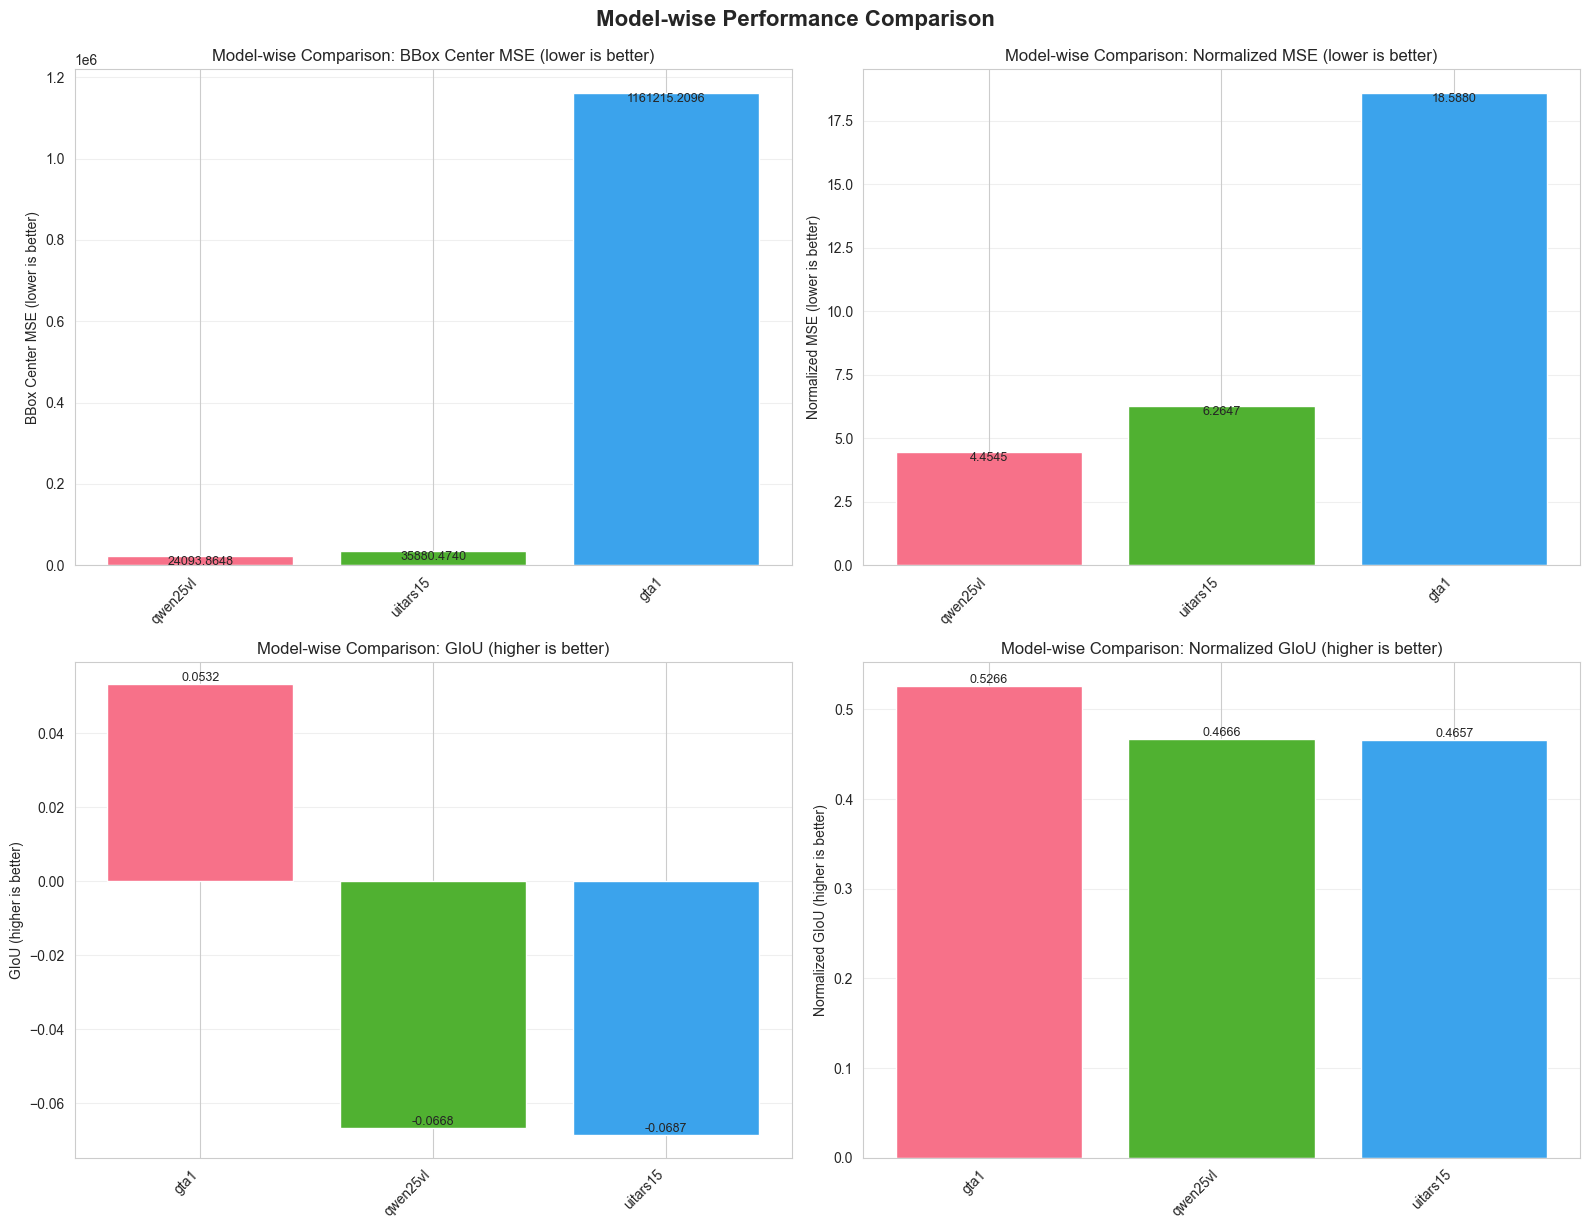


Model-wise Summary Statistics:

BBox Center MSE (lower is better):
                  mean           std  count
model                                      
gta1      1.161215e+06  9.387079e+07   6864
qwen25vl  2.409386e+04  1.354319e+05   6848
uitars15  3.588047e+04  1.714566e+05   6842

Normalized MSE (lower is better):
             mean        std  count
model                              
gta1      18.5880  1087.8614   6864
qwen25vl   4.4545    28.9152   6848
uitars15   6.2647    46.9091   6842

GIoU (higher is better):
            mean     std  count
model                          
gta1      0.0532  0.4078   6864
qwen25vl -0.0668  0.4254   6848
uitars15 -0.0687  0.4487   6842

Normalized GIoU (higher is better):
            mean     std  count
model                          
gta1      0.5266  0.2039   6864
qwen25vl  0.4666  0.2127   6848
uitars15  0.4657  0.2244   6842


In [359]:
# 1. Model-wise comparison
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, metric in enumerate(metrics):
    ax = axes[idx]
    
    # Calculate mean for each model
    model_means = df_plot.groupby('model')[metric].mean().sort_values(ascending=(metric in ['bbox_center_mse', 'normalized_mse']))
    
    # Create bar plot
    bars = ax.bar(range(len(model_means)), model_means.values, color=sns.color_palette("husl", len(model_means)))
    ax.set_xticks(range(len(model_means)))
    ax.set_xticklabels(model_means.index, rotation=45, ha='right')
    ax.set_ylabel(metric_labels[metric])
    ax.set_title(f'Model-wise Comparison: {metric_labels[metric]}')
    ax.grid(axis='y', alpha=0.3)
    
    # Add value labels on bars
    for i, (bar, val) in enumerate(zip(bars, model_means.values)):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{val:.4f}',
                ha='center', va='bottom' if metric in ['giou', 'ngiou'] else 'top', fontsize=9)

plt.tight_layout()
plt.suptitle('Model-wise Performance Comparison', y=1.02, fontsize=16, fontweight='bold')
plt.show()

# Print summary statistics
print("\nModel-wise Summary Statistics:")
print("="*80)
for metric in metrics:
    print(f"\n{metric_labels[metric]}:")
    print(df_plot.groupby('model')[metric].agg(['mean', 'std', 'count']).round(4))


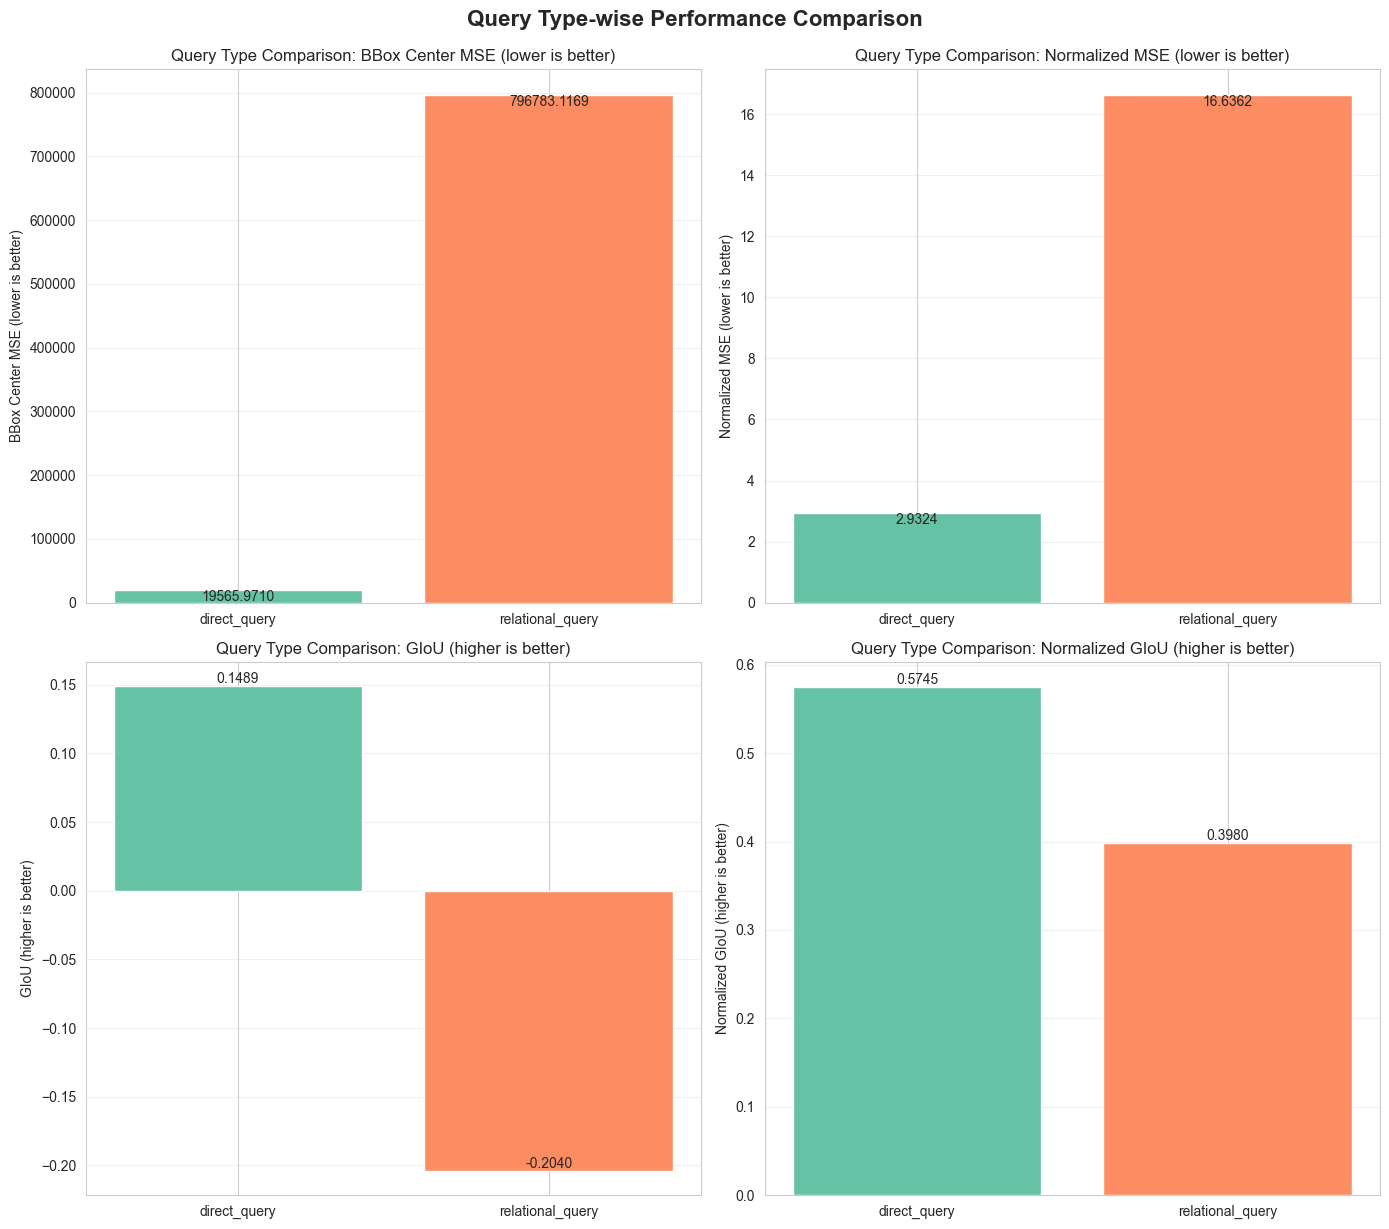


Query Type-wise Summary Statistics:

BBox Center MSE (lower is better):
                         mean           std  count
query_type                                        
direct_query       19565.9710  1.298562e+05  10288
relational_query  796783.1169  7.675707e+07  10266

Normalized MSE (lower is better):
                     mean       std  count
query_type                                
direct_query       2.9324   31.7044  10288
relational_query  16.6362  890.0735  10266

GIoU (higher is better):
                    mean     std  count
query_type                             
direct_query      0.1489  0.3200  10288
relational_query -0.2040  0.4557  10266

Normalized GIoU (higher is better):
                    mean     std  count
query_type                             
direct_query      0.5745  0.1600  10288
relational_query  0.3980  0.2278  10266


In [360]:
# 2. Query_type-wise comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for idx, metric in enumerate(metrics):
    ax = axes[idx]
    
    # Calculate mean for each query_type
    query_means = df_plot.groupby('query_type')[metric].mean().sort_values(ascending=(metric in ['bbox_center_mse', 'normalized_mse']))
    
    # Create bar plot
    bars = ax.bar(range(len(query_means)), query_means.values, color=sns.color_palette("Set2", len(query_means)))
    ax.set_xticks(range(len(query_means)))
    ax.set_xticklabels(query_means.index, rotation=0, ha='center')
    ax.set_ylabel(metric_labels[metric])
    ax.set_title(f'Query Type Comparison: {metric_labels[metric]}')
    ax.grid(axis='y', alpha=0.3)
    
    # Add value labels on bars
    for bar, val in zip(bars, query_means.values):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{val:.4f}',
                ha='center', va='bottom' if metric in ['giou', 'ngiou'] else 'top', fontsize=10)

plt.tight_layout()
plt.suptitle('Query Type-wise Performance Comparison', y=1.02, fontsize=16, fontweight='bold')
plt.show()

# Print summary statistics
print("\nQuery Type-wise Summary Statistics:")
print("="*80)
for metric in metrics:
    print(f"\n{metric_labels[metric]}:")
    print(df_plot.groupby('query_type')[metric].agg(['mean', 'std', 'count']).round(4))


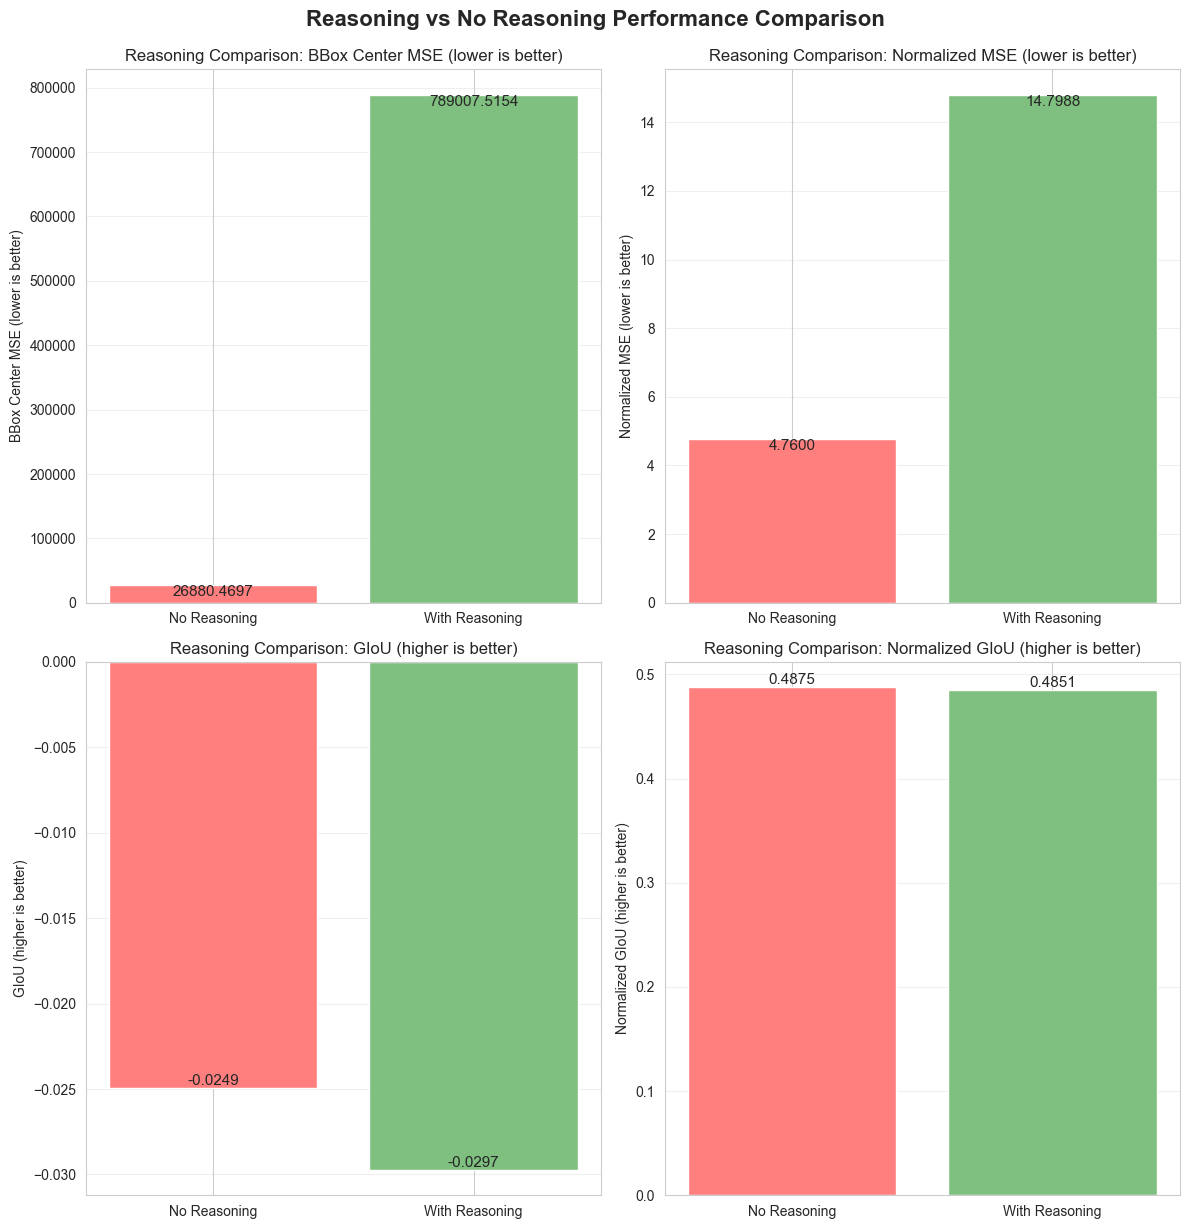


Reasoning-wise Summary Statistics:

BBox Center MSE (lower is better):
                       mean           std  count
No Reasoning     26880.4697  1.496988e+05  10282
With Reasoning  789007.5154  7.673469e+07  10272

Normalized MSE (lower is better):
                   mean       std  count
No Reasoning     4.7600   41.7526  10282
With Reasoning  14.7988  889.4231  10272

GIoU (higher is better):
                  mean     std  count
No Reasoning   -0.0249  0.4270  10282
With Reasoning -0.0297  0.4357  10272

Normalized GIoU (higher is better):
                  mean     std  count
No Reasoning    0.4875  0.2135  10282
With Reasoning  0.4851  0.2179  10272


In [361]:
# 3. Use_reasoning-wise comparison
fig, axes = plt.subplots(2, 2, figsize=(12, 12))
axes = axes.flatten()

for idx, metric in enumerate(metrics):
    ax = axes[idx]
    
    # Calculate mean for each use_reasoning value
    reasoning_means = df_plot.groupby('use_reasoning')[metric].mean().sort_index()
    reasoning_labels = ['No Reasoning' if not x else 'With Reasoning' for x in reasoning_means.index]
    
    # Create bar plot
    bars = ax.bar(range(len(reasoning_means)), reasoning_means.values, 
                  color=['#ff7f7f', '#7fbf7f'] if len(reasoning_means) == 2 else sns.color_palette("pastel", len(reasoning_means)))
    ax.set_xticks(range(len(reasoning_means)))
    ax.set_xticklabels(reasoning_labels, rotation=0, ha='center')
    ax.set_ylabel(metric_labels[metric])
    ax.set_title(f'Reasoning Comparison: {metric_labels[metric]}')
    ax.grid(axis='y', alpha=0.3)
    
    # Add value labels on bars
    for bar, val in zip(bars, reasoning_means.values):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{val:.4f}',
                ha='center', va='bottom' if metric in ['giou', 'ngiou'] else 'top', fontsize=11)

plt.tight_layout()
plt.suptitle('Reasoning vs No Reasoning Performance Comparison', y=1.02, fontsize=16, fontweight='bold')
plt.show()

# Print summary statistics
print("\nReasoning-wise Summary Statistics:")
print("="*80)
for metric in metrics:
    print(f"\n{metric_labels[metric]}:")
    stats = df_plot.groupby('use_reasoning')[metric].agg(['mean', 'std', 'count']).round(4)
    stats.index = ['No Reasoning' if not x else 'With Reasoning' for x in stats.index]
    print(stats)


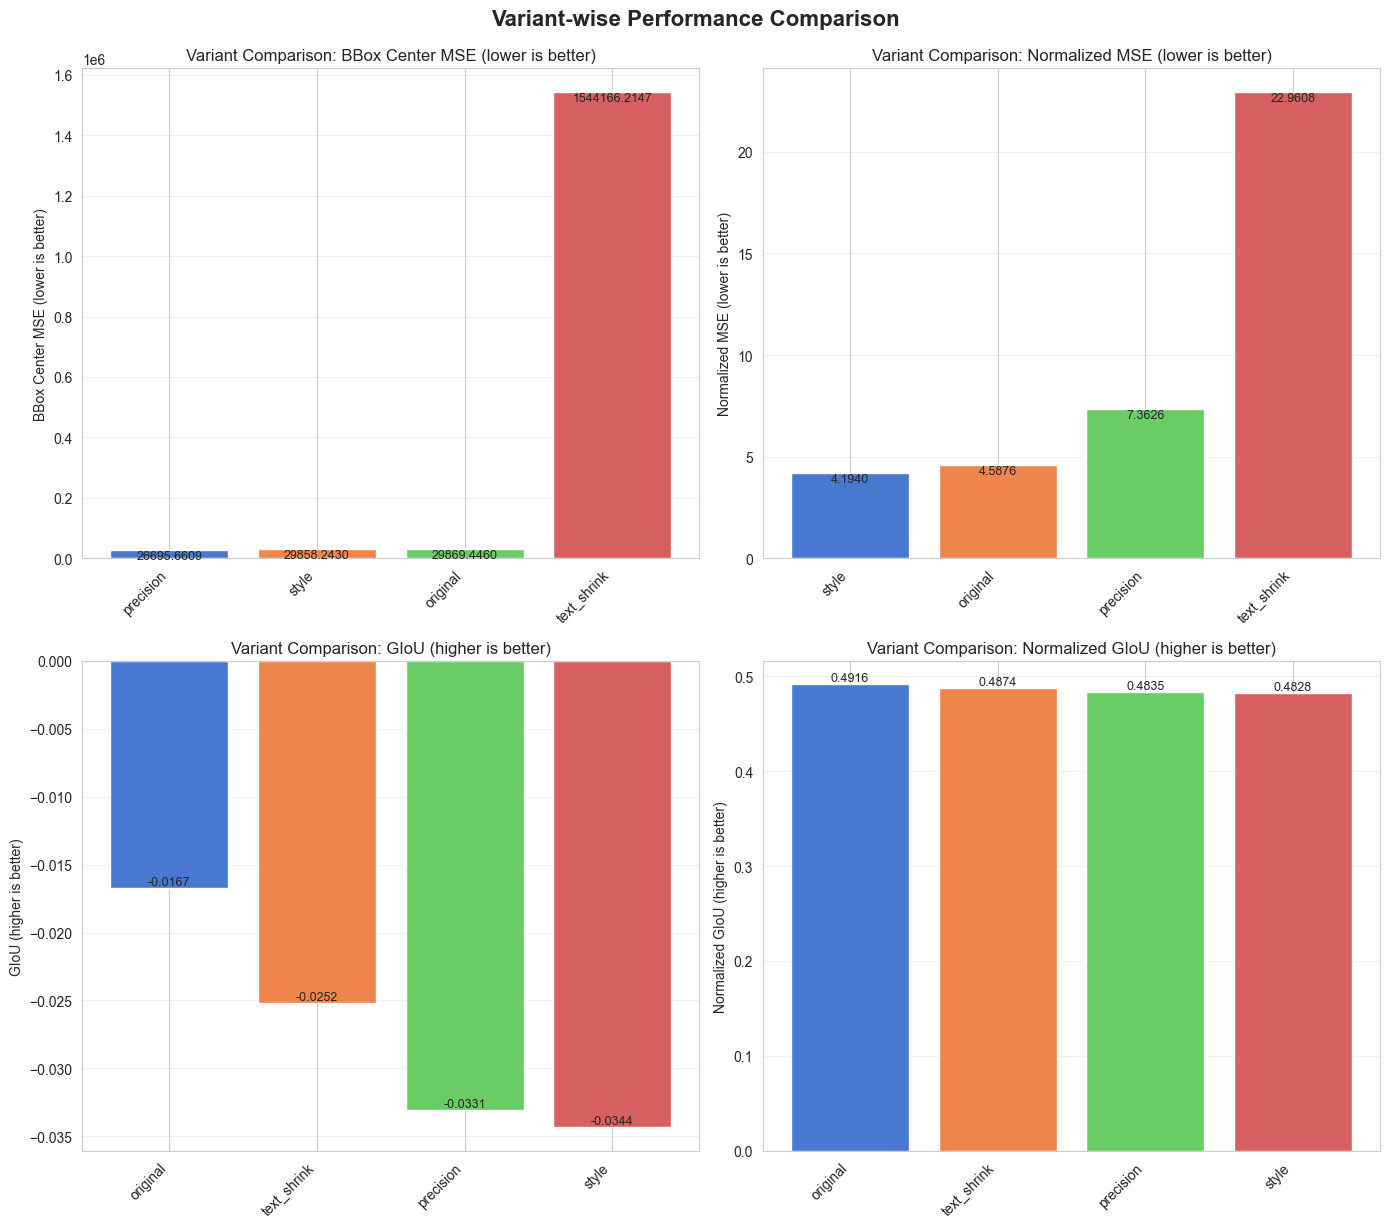


Variant-wise Summary Statistics:

BBox Center MSE (lower is better):
                     mean           std  count
variant                                       
original     2.986945e+04  1.494000e+05   5140
precision    2.669566e+04  1.458893e+05   5134
style        2.985824e+04  1.496236e+05   5140
text_shrink  1.544166e+06  1.084769e+08   5140

Normalized MSE (lower is better):
                mean        std  count
variant                               
original      4.5876    35.4162   5140
precision     7.3626    56.3621   5134
style         4.1940    31.8719   5140
text_shrink  22.9608  1256.5734   5140

GIoU (higher is better):
               mean     std  count
variant                           
original    -0.0167  0.4263   5140
precision   -0.0331  0.4475   5134
style       -0.0344  0.4228   5140
text_shrink -0.0252  0.4284   5140

Normalized GIoU (higher is better):
               mean     std  count
variant                           
original     0.4916  0.2132   5140
p

In [362]:
# 4. Variant-wise comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for idx, metric in enumerate(metrics):
    ax = axes[idx]
    
    # Calculate mean for each variant
    variant_means = df_plot.groupby('variant')[metric].mean().sort_values(ascending=(metric in ['bbox_center_mse', 'normalized_mse']))
    
    # Create bar plot
    bars = ax.bar(range(len(variant_means)), variant_means.values, color=sns.color_palette("muted", len(variant_means)))
    ax.set_xticks(range(len(variant_means)))
    ax.set_xticklabels(variant_means.index, rotation=45, ha='right')
    ax.set_ylabel(metric_labels[metric])
    ax.set_title(f'Variant Comparison: {metric_labels[metric]}')
    ax.grid(axis='y', alpha=0.3)
    
    # Add value labels on bars
    for bar, val in zip(bars, variant_means.values):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{val:.4f}',
                ha='center', va='bottom' if metric in ['giou', 'ngiou'] else 'top', fontsize=9)

plt.tight_layout()
plt.suptitle('Variant-wise Performance Comparison', y=1.02, fontsize=16, fontweight='bold')
plt.show()

# Print summary statistics
print("\nVariant-wise Summary Statistics:")
print("="*80)
for metric in metrics:
    print(f"\n{metric_labels[metric]}:")
    print(df_plot.groupby('variant')[metric].agg(['mean', 'std', 'count']).round(4))


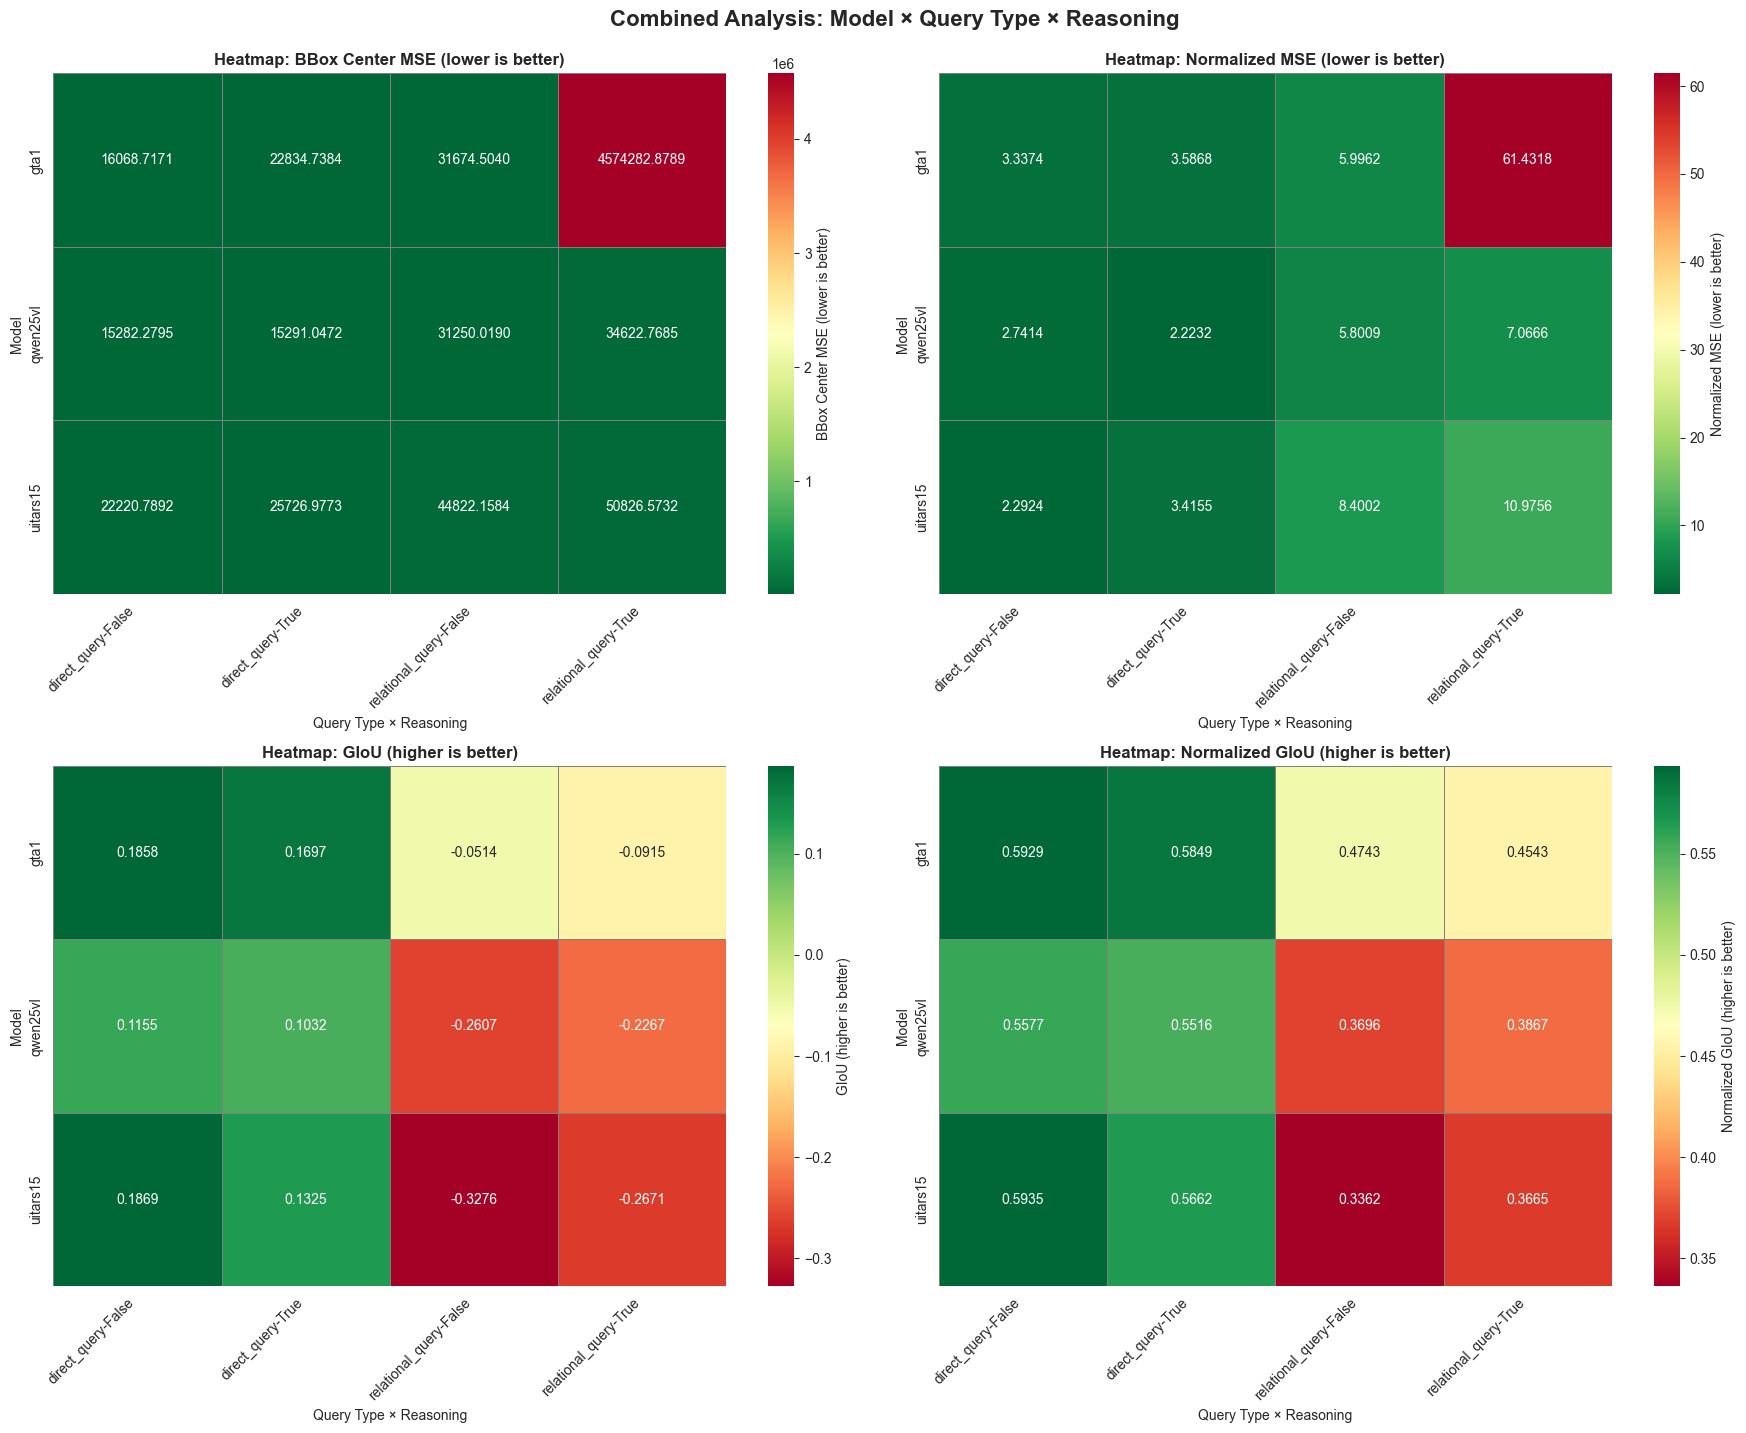

In [363]:
# 5. Combined visualizations: Model x Query Type x Reasoning
# Create heatmaps for key metrics

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
axes = axes.flatten()

for idx, metric in enumerate(metrics):
    ax = axes[idx]
    
    # Create pivot table: model vs (query_type, use_reasoning)
    pivot_data = df_plot.pivot_table(
        values=metric,
        index='model',
        columns=['query_type', 'use_reasoning'],
        aggfunc='mean'
    )
    
    # Create heatmap
    sns.heatmap(pivot_data, annot=True, fmt='.4f', cmap='RdYlGn_r' if metric in ['bbox_center_mse', 'normalized_mse'] else 'RdYlGn',
                ax=ax, cbar_kws={'label': metric_labels[metric]}, linewidths=0.5, linecolor='gray')
    ax.set_title(f'Heatmap: {metric_labels[metric]}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Query Type × Reasoning', fontsize=10)
    ax.set_ylabel('Model', fontsize=10)
    
    # Rotate x-axis labels
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.suptitle('Combined Analysis: Model × Query Type × Reasoning', y=1.02, fontsize=16, fontweight='bold')
plt.show()


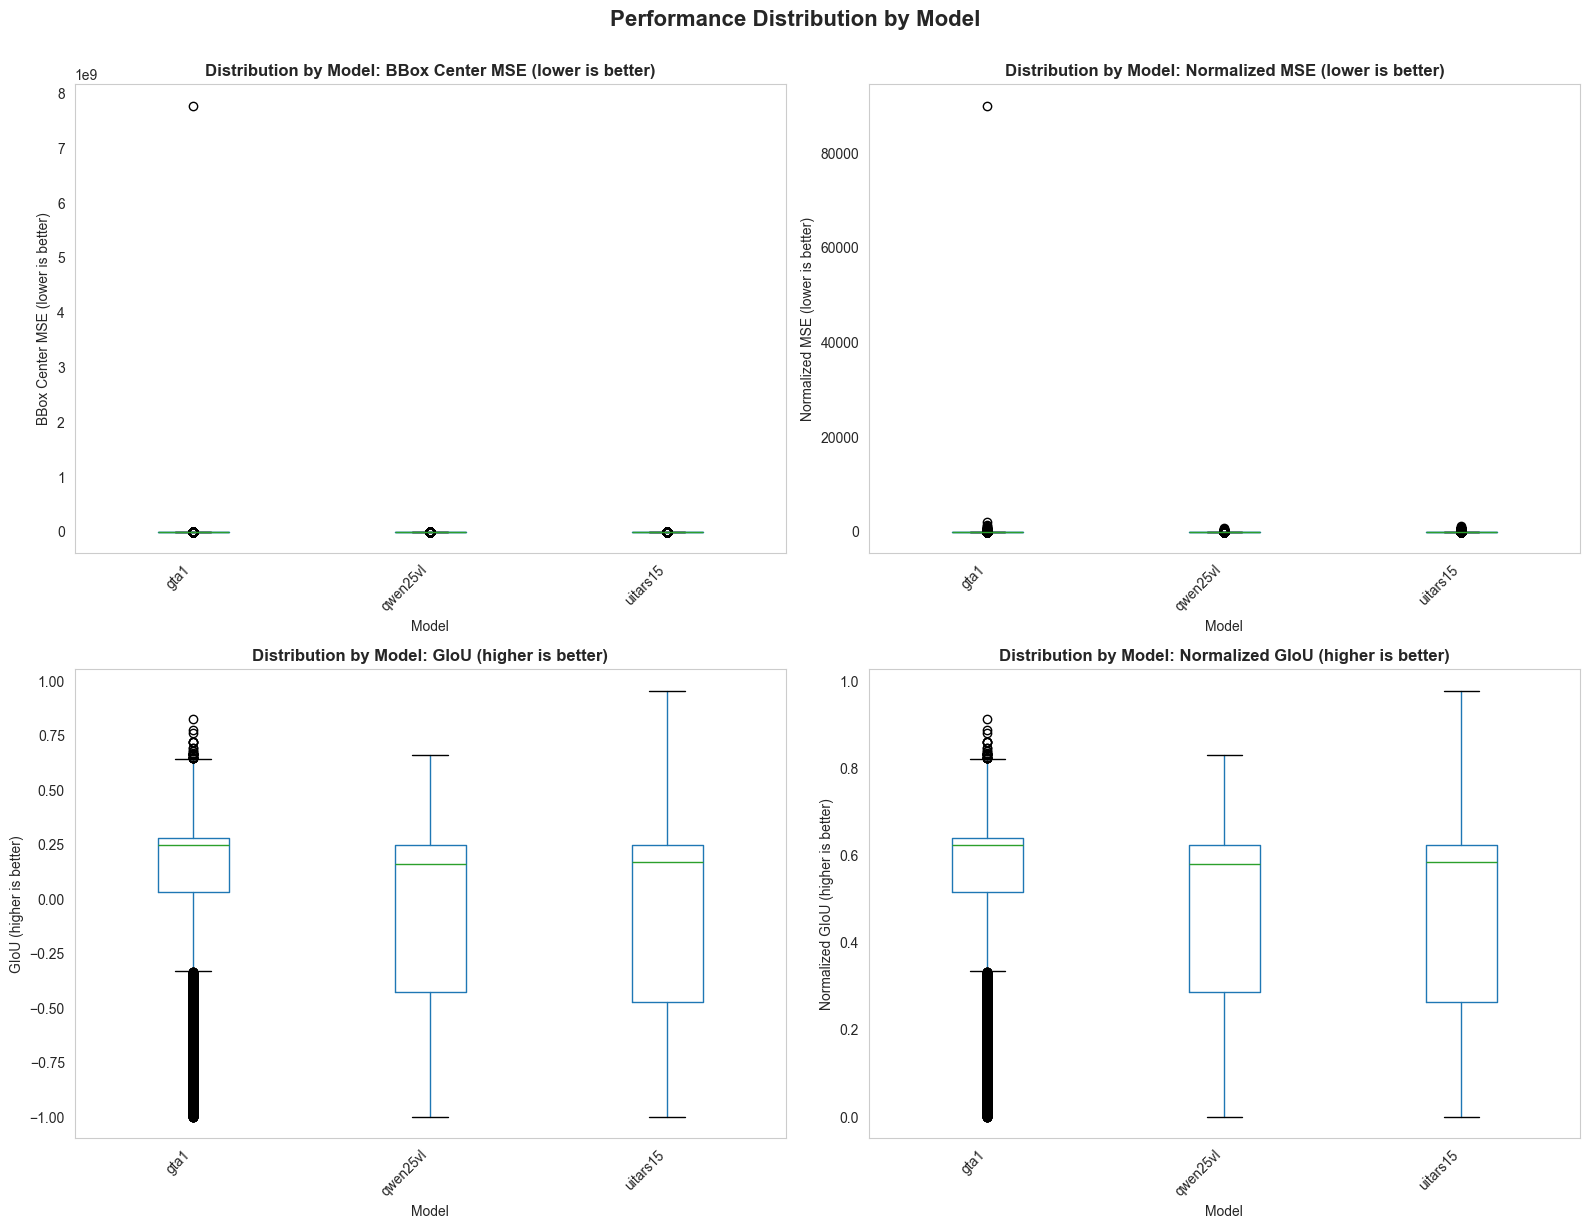

In [365]:
# 6. Box plots for distribution analysis
# Model-wise distributions
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, metric in enumerate(metrics):
    ax = axes[idx]
    
    # Create box plot
    df_plot.boxplot(column=metric, by='model', ax=ax, grid=False)
    ax.set_title(f'Distribution by Model: {metric_labels[metric]}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Model', fontsize=10)
    ax.set_ylabel(metric_labels[metric], fontsize=10)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    plt.suptitle('')  # Remove default title

plt.tight_layout()
plt.suptitle('Performance Distribution by Model', y=1.02, fontsize=16, fontweight='bold')
plt.show()


In [364]:
# 7. Comprehensive summary table
print("="*100)
print("COMPREHENSIVE PERFORMANCE SUMMARY")
print("="*100)

# Create summary tables for each dimension
summary_tables = {}

print("\n1. MODEL-WISE SUMMARY (Mean ± Std)")
print("-" * 100)
model_summary = df_plot.groupby('model')[metrics].agg(['mean', 'std']).round(4)
for model in model_summary.index:
    print(f"\n{model}:")
    for metric in metrics:
        mean_val = model_summary.loc[model, (metric, 'mean')]
        std_val = model_summary.loc[model, (metric, 'std')]
        print(f"  {metric_labels[metric]:40s}: {mean_val:8.4f} ± {std_val:8.4f}")

print("\n\n2. QUERY TYPE-WISE SUMMARY (Mean ± Std)")
print("-" * 100)
query_summary = df_plot.groupby('query_type')[metrics].agg(['mean', 'std']).round(4)
for query_type in query_summary.index:
    print(f"\n{query_type}:")
    for metric in metrics:
        mean_val = query_summary.loc[query_type, (metric, 'mean')]
        std_val = query_summary.loc[query_type, (metric, 'std')]
        print(f"  {metric_labels[metric]:40s}: {mean_val:8.4f} ± {std_val:8.4f}")

print("\n\n3. REASONING-WISE SUMMARY (Mean ± Std)")
print("-" * 100)
reasoning_summary = df_plot.groupby('use_reasoning')[metrics].agg(['mean', 'std']).round(4)
for reasoning in reasoning_summary.index:
    reasoning_label = 'With Reasoning' if reasoning else 'No Reasoning'
    print(f"\n{reasoning_label}:")
    for metric in metrics:
        mean_val = reasoning_summary.loc[reasoning, (metric, 'mean')]
        std_val = reasoning_summary.loc[reasoning, (metric, 'std')]
        print(f"  {metric_labels[metric]:40s}: {mean_val:8.4f} ± {std_val:8.4f}")

print("\n\n4. VARIANT-WISE SUMMARY (Mean ± Std)")
print("-" * 100)
variant_summary = df_plot.groupby('variant')[metrics].agg(['mean', 'std']).round(4)
for variant in variant_summary.index:
    print(f"\n{variant}:")
    for metric in metrics:
        mean_val = variant_summary.loc[variant, (metric, 'mean')]
        std_val = variant_summary.loc[variant, (metric, 'std')]
        print(f"  {metric_labels[metric]:40s}: {mean_val:8.4f} ± {std_val:8.4f}")

print("\n" + "="*100)


COMPREHENSIVE PERFORMANCE SUMMARY

1. MODEL-WISE SUMMARY (Mean ± Std)
----------------------------------------------------------------------------------------------------

gta1:
  BBox Center MSE (lower is better)       : 1161215.2096 ± 93870789.1208
  Normalized MSE (lower is better)        :  18.5880 ± 1087.8614
  GIoU (higher is better)                 :   0.0532 ±   0.4078
  Normalized GIoU (higher is better)      :   0.5266 ±   0.2039

qwen25vl:
  BBox Center MSE (lower is better)       : 24093.8648 ± 135431.8809
  Normalized MSE (lower is better)        :   4.4545 ±  28.9152
  GIoU (higher is better)                 :  -0.0668 ±   0.4254
  Normalized GIoU (higher is better)      :   0.4666 ±   0.2127

uitars15:
  BBox Center MSE (lower is better)       : 35880.4740 ± 171456.6312
  Normalized MSE (lower is better)        :   6.2647 ±  46.9091
  GIoU (higher is better)                 :  -0.0687 ±   0.4487
  Normalized GIoU (higher is better)      :   0.4657 ±   0.2244


2. QUERY T